# Master Hospital Model Experiments

## Comprehensive Simulation Studies for SEIXHRD Epidemic Model

This notebook demonstrates our master hospital model through a series of structured experiments organized by scientific question. Each section explores a fundamental aspect of epidemic dynamics and healthcare capacity constraints.

### Mathematical Foundation

The model tracks individuals through compartments $S \to E \to I \to X \to H \to R$ or $D$, implementing:

1. **Three-Factor Vaccine Efficacy**:
   - $VE_I$: Efficacy against infection (reduces force of infection)
   - $VE_S$: Efficacy against severe disease (reduces $I \to X$ progression)  
   - $VE_D$: Efficacy against death (reduces mortality rates)

This allows for more nuanced vaccine modeling compared to our previous Leaky Model.

2. **Hospital Capacity Constraints** via Hill function gating:
$$g(H) = \frac{1}{1 + \left(\frac{H}{K}\right)^n}$$

This modulates progression rates to hospitalization and mortality based on current hospital load $H$ relative to capacity $K$.

3. **Age-Structured Force of Infection**:
$$\lambda_a = \beta(t) \sum_b C_{ab} \frac{I_b + \theta_X X_b + \theta_H H_b}{N_b}$$

This captures more realistic transmission dynamics across age groups using a contact matrix $C_{ab}$.

---

**Notebook Structure:**
Setup & Imports
Scenario Overview: What configurations are available?
Experiment 1: Impact of Vaccine Type (Three-Factor Model)
Experiment 2: Healthcare System Stress Testing
Experiment 3: Intervention Timing & Strategy
Experiment 4: Transmission Rate Sensitivity ($\beta$ Sweeps)
Experiment 5: Capacity Threshold Analysis
Experiment 6: Endemic Equilibrium Dynamics
Summary & Conclusions

## Setup & Imports

In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath('..'))

# Core imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings

# Model imports
from master_hospital_model import simulate_master_hospital_model
from config_helpers import (
    # Scenario utilities
    get_scenario_params,
    run_scenario_with_overrides,
    validate_scenario_params,
    get_all_scenario_names,
    summarize_scenarios,
    
    # Comparison utilities
    compare_vaccine_profiles,
    compare_healthcare_systems,
    create_sensitivity_variants,
    create_intervention_comparison,
    
    # Vaccine profile utilities
    get_vaccine_profile,
    list_vaccine_profiles,
    
    # Healthcare systems
    get_healthcare_systems,
)
from config import (
    # Scenario access
    SCENARIO_REGISTRY,
    
    # Core configurations
    AGE_PARAMS_EMPIRICAL,
    CONTACT_MATRIX_DEFAULT,
    TRANSMISSION_PRESETS,
    DEMOGRAPHIC_PARAMS_DEFAULT,
    
    # Vaccine profiles
    VACCINE_PROFILES,
    
    # Intervention templates
    INTERVENTION_NONE,
    INTERVENTION_EARLY_STRONG,
    INTERVENTION_EARLY_MODERATE,
    INTERVENTION_DELAYED_STRONG,
    INTERVENTION_DELAYED_MODERATE,
    INTERVENTION_CYCLICAL,
    INTERVENTION_TIERED_ESCALATING,
)

# Display settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.style.use('seaborn-v0_8-whitegrid')

# Suppress specific warnings for cleaner output
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("✓ All imports successful")
print(f"✓ {len(get_all_scenario_names())} scenarios available")
print(f"✓ {len(list_vaccine_profiles())} vaccine profiles available")

✓ All imports successful
✓ 24 scenarios available
✓ 7 vaccine profiles available


## Scenario Overview

First, let's examine all available pre-configured scenarios. Each scenario bundles transmission parameters, healthcare system capacity, vaccination strategies, and intervention timings into an easy-to-use configuration.

In [2]:
# List all available scenarios
print(summarize_scenarios())

AVAILABLE SCENARIOS

baseline:
  Default moderate outbreak in urban setting, no interventions
  β_base = 0.28, Tmax = 200

capacity_collapse:
  Severe outbreak overwhelming minimal healthcare infrastructure
  β_base = 0.45, Tmax = 200

care_home_outbreak:
  Outbreak starting in elderly care facility
  β_base = 0.28, Tmax = 150

covid_delta:
  High transmission Delta variant with partial vaccination
  β_base = 0.38, Tmax = 365

covid_early_2020:
  Early pandemic wave, no vaccines, delayed lockdown
  β_base = 0.28, Tmax = 200

covid_omicron:
  Very high transmission but lower severity, high immunity
  β_base = 0.45, Tmax = 200

cyclical_policy:
  Testing on-off lockdown strategies
  β_base = 0.28, Tmax = 250

endemic:
  Long-term endemic dynamics with waning immunity
  β_base = 0.28, Tmax = 730

endemic_vaccination:
  Long-term endemic equilibrium with seasonal vaccination campaigns
  β_base = 0.18, Tmax = 730
  Vaccine: influenza_typical

late_onset:
  Mild outbreak with late seasonal p

In [3]:
# Show vaccine profiles with their Three-Factor efficacy parameters
print("\n" + "="*70)
print("VACCINE PROFILES (Three-Factor Model)")
print("="*70)

for name in list_vaccine_profiles():
    profile = get_vaccine_profile(name)
    waning = f"~{1/profile['omega_vax']:.0f}d" if profile['omega_vax'] > 0 else "∞"
    print(f"\n{name}:")
    print(f"  {profile['description']}")
    print(f"  VE_infection={profile['VE_infection']:.0%}, "
          f"VE_severe={profile['VE_severe']:.0%}, "
          f"VE_death={profile['VE_death']:.0%}")
    print(f"  θ_vax={profile['theta_vax']:.0%}, waning={waning}")


VACCINE PROFILES (Three-Factor Model)

mrna_original:
  mRNA vaccine (Pfizer/Moderna) vs original strain
  VE_infection=80%, VE_severe=90%, VE_death=95%
  θ_vax=30%, waning=~500d

mrna_omicron:
  mRNA vaccine vs Omicron variant (immune escape)
  VE_infection=30%, VE_severe=70%, VE_death=85%
  θ_vax=60%, waning=~250d

adenovirus:
  Adenovirus vaccine (AZ/J&J)
  VE_infection=65%, VE_severe=85%, VE_death=90%
  θ_vax=40%, waning=~333d

inactivated:
  Inactivated virus vaccine (Sinovac/Sinopharm)
  VE_infection=50%, VE_severe=70%, VE_death=80%
  θ_vax=50%, waning=~250d

influenza_typical:
  Typical seasonal influenza vaccine
  VE_infection=40%, VE_severe=60%, VE_death=75%
  θ_vax=60%, waning=~333d

ideal:
  Ideal/sterilizing vaccine
  VE_infection=95%, VE_severe=99%, VE_death=99%
  θ_vax=10%, waning=∞

minimal:
  Minimal/suboptimal vaccine
  VE_infection=30%, VE_severe=50%, VE_death=60%
  θ_vax=70%, waning=~200d


## Experiment 1: Impact of Vaccine Type (Three-Factor Model)

### Scientific Question
*How do different vaccine technologies affect epidemic outcomes when we model protection against infection, severe disease, and death separately?*

### Mathematical Background
The Three-Factor Vaccine Model provides more realistic vaccine modeling than single-efficacy approaches. For vaccinated individuals, we apply:

$$\lambda_{\text{vax}} = (1 - VE_I) \cdot \lambda$$

$$\sigma_{\text{vax}} = (1 - VE_S) \cdot \sigma$$

$$\mu_{\text{vax}} = (1 - VE_D) \cdot \mu$$

Where:
- $VE_I$ = efficacy against **infection** (reduces susceptibility)
- $VE_S$ = efficacy against **severe disease** (reduces $I \to X$ progression rate $\sigma$)
- $VE_D$ = efficacy against **death** (reduces mortality rates $\mu$)

### Why This Matters
Real-world vaccines show different levels of protection against infection vs hospitalization vs death. For example, mRNA vaccines against COVID-19 Omicron showed ~30% protection against infection but ~85% against death. This has critical implications for:
- **Transmission control**: Low $VE_I$ means vaccinated can still spread disease
- **Healthcare burden**: High $VE_S$ prevents hospital overcrowding
- **Mortality reduction**: High $VE_D$ is the ultimate goal of vaccination

In [4]:
# Compare vaccine profiles using the COVID-Delta scenario as baseline
vaccine_scenarios = compare_vaccine_profiles(
    base_scenario='covid_delta',
    profile_names=['minimal', 'adenovirus', 'mrna_original', 'mrna_omicron', 'inactivated', 'influenza_typical', 'ideal' ],
    include_no_vaccine=True
)

# Run simulations
vaccine_results = {}
for name, params in vaccine_scenarios.items():
    print(f"Running simulation: {name}...")
    vaccine_results[name] = simulate_master_hospital_model(**params)
    
print(f"\n✓ Completed {len(vaccine_results)} simulations")

Running simulation: no_vaccine...
Running simulation: minimal...
Running simulation: adenovirus...
Running simulation: mrna_original...
Running simulation: mrna_omicron...
Running simulation: inactivated...
Running simulation: influenza_typical...
Running simulation: ideal...

✓ Completed 8 simulations


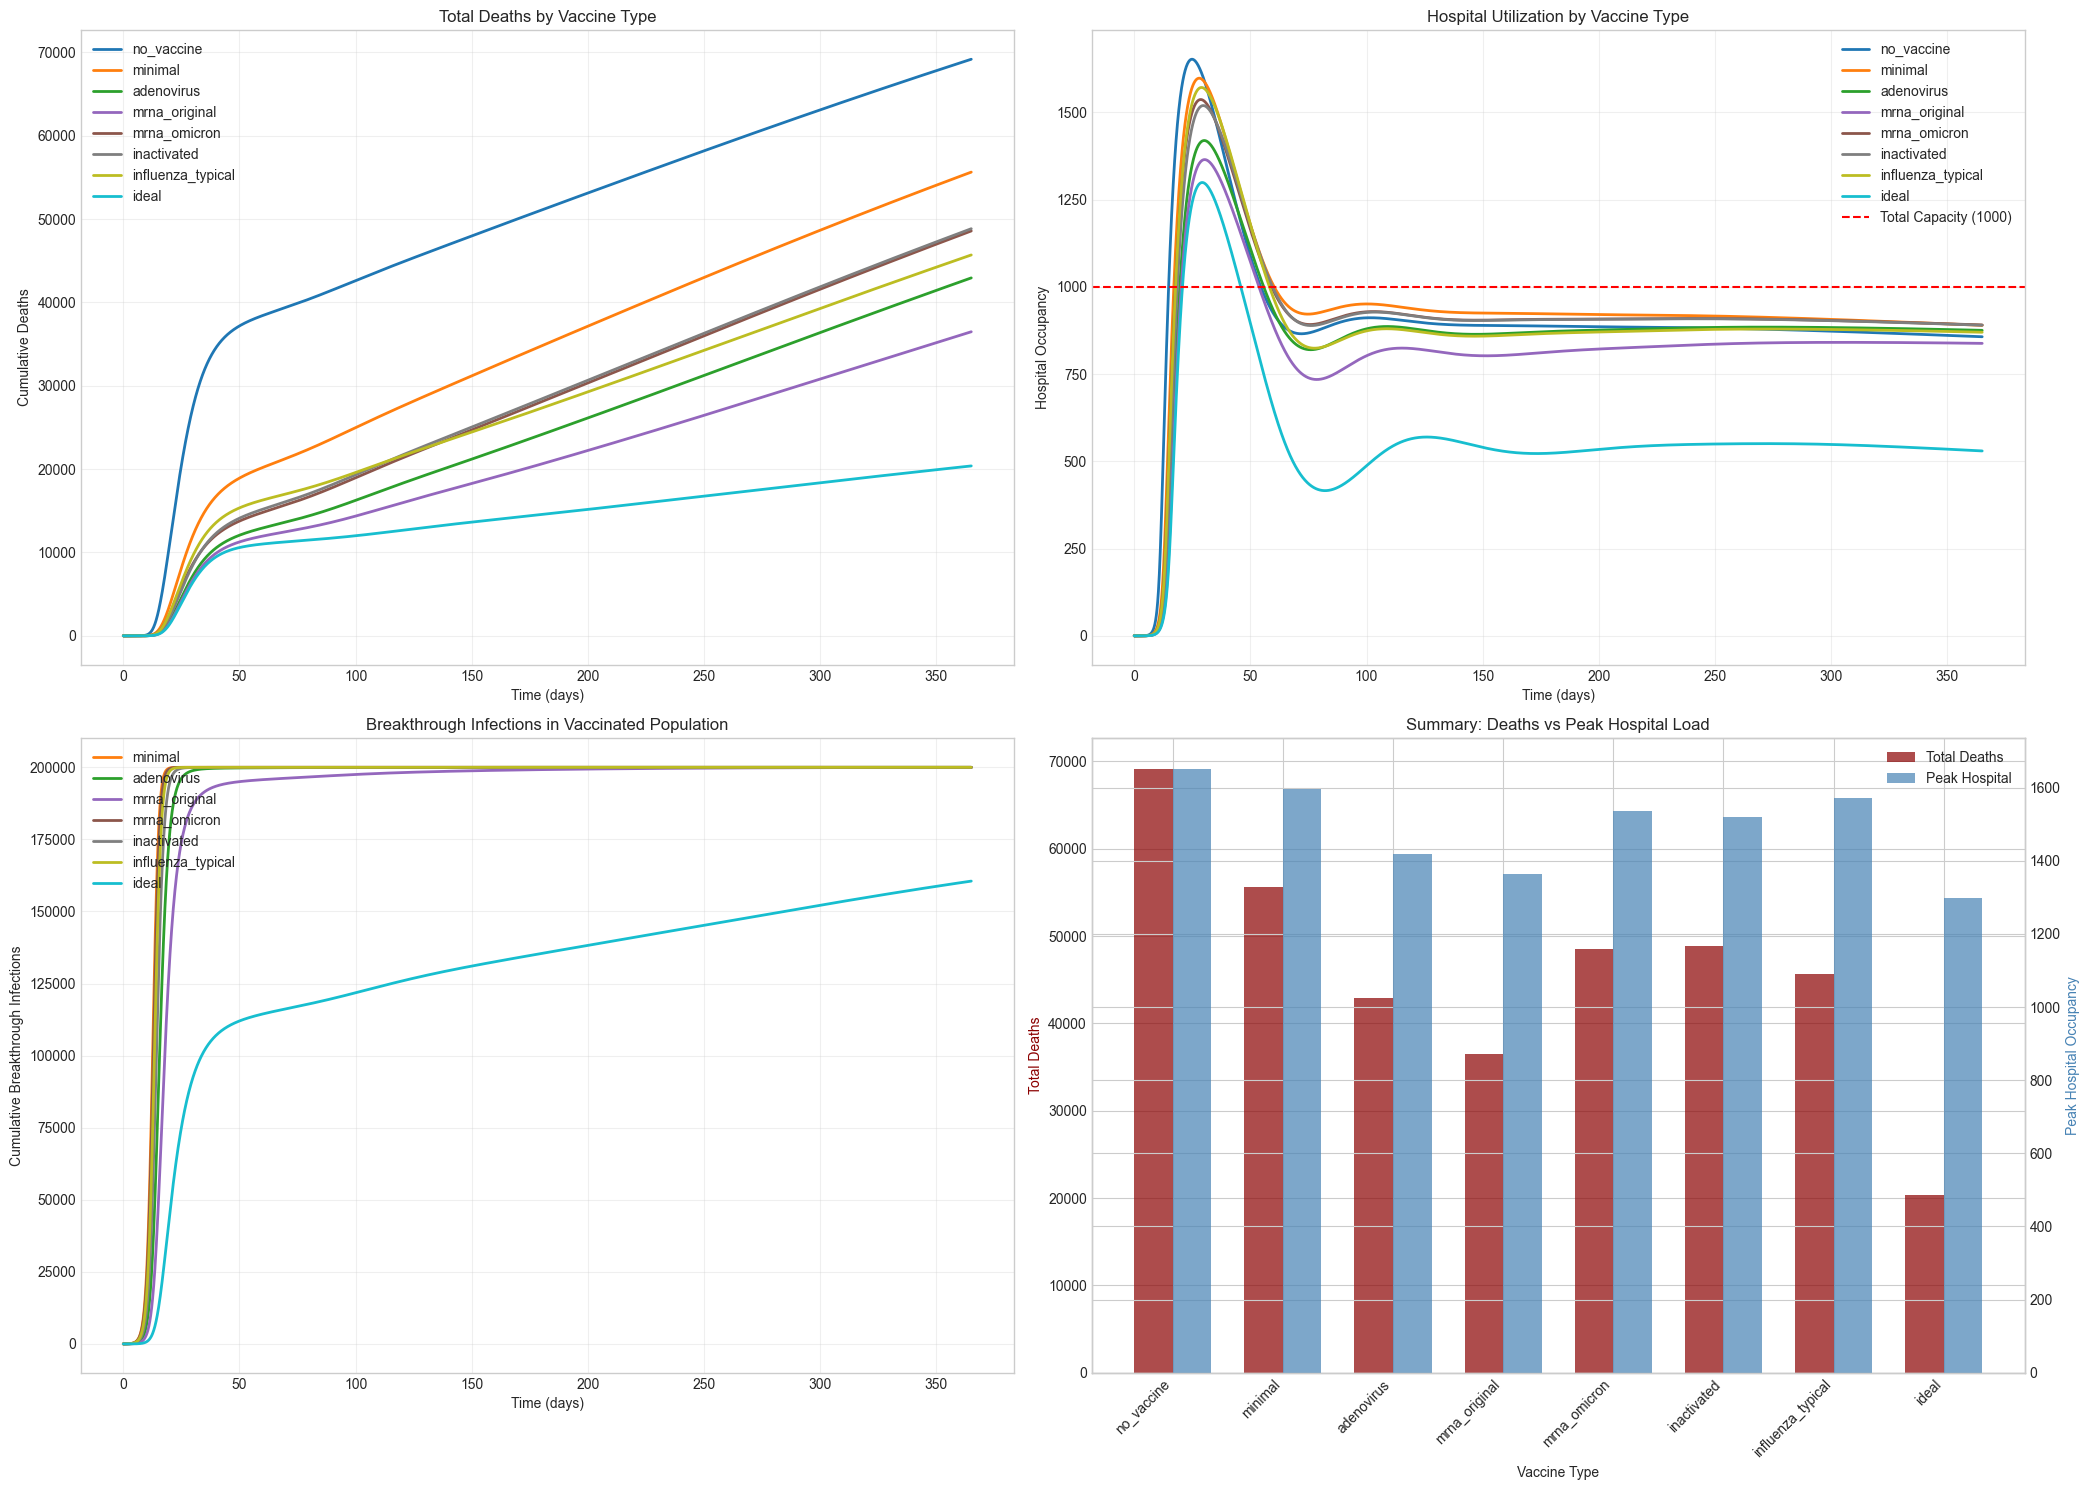


VACCINE COMPARISON SUMMARY
Vaccine                  Deaths     Peak H Breakthrough
----------------------------------------------------------------------
no_vaccine                69170       1652            0
minimal                   55630       1598       199997
adenovirus                42939       1419       199997
mrna_original             36478       1364       199970
mrna_omicron              48571       1537       199997
inactivated               48839       1519       199997
influenza_typical         45692       1571       199997
ideal                     20383       1299       160532


In [5]:
# Visualize vaccine comparison results
fig, axes = plt.subplots(2, 2, figsize=(21, 15))

colors = plt.cm.tab10(np.linspace(0, 1, len(vaccine_results)))

# Panel 1: Total Deaths Over Time
ax1 = axes[0, 0]
for i, (name, res) in enumerate(vaccine_results.items()):
    ax1.plot(res['times'], res['D_total'], label=name, color=colors[i], linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Cumulative Deaths')
ax1.set_title('Total Deaths by Vaccine Type')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Panel 2: Peak Hospital Occupancy
ax2 = axes[0, 1]
for i, (name, res) in enumerate(vaccine_results.items()):
    ax2.plot(res['times'], res['H_total'], label=name, color=colors[i], linewidth=2)
ax2.axhline(y=res['ward_capacity'] + res['icu_capacity'], color='red', linestyle='--', 
            label=f"Total Capacity ({res['ward_capacity'] + res['icu_capacity']})")
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Hospital Occupancy')
ax2.set_title('Hospital Utilization by Vaccine Type')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Panel 3: Breakthrough Infections (Vaccinated)
ax3 = axes[1, 0]
for i, (name, res) in enumerate(vaccine_results.items()):
    if name != 'no_vaccine':
        ax3.plot(res['times'], res['breakthrough_infections'], label=name, color=colors[i], linewidth=2)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Cumulative Breakthrough Infections')
ax3.set_title('Breakthrough Infections in Vaccinated Population')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# Panel 4: Summary Bar Chart
ax4 = axes[1, 1]
names = list(vaccine_results.keys())
final_deaths = [res['D_total'][-1] for res in vaccine_results.values()]
peak_H = [max(res['H_total']) for res in vaccine_results.values()]

x = np.arange(len(names))
width = 0.35

bars1 = ax4.bar(x - width/2, final_deaths, width, label='Total Deaths', color='darkred', alpha=0.7)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, peak_H, width, label='Peak Hospital', color='steelblue', alpha=0.7)

ax4.set_xlabel('Vaccine Type')
ax4.set_ylabel('Total Deaths', color='darkred')
ax4_twin.set_ylabel('Peak Hospital Occupancy', color='steelblue')
ax4.set_xticks(x)
ax4.set_xticklabels(names, rotation=45, ha='right')
ax4.set_title('Summary: Deaths vs Peak Hospital Load')

# Combined legend
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax4_twin.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('../results/vaccine_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("VACCINE COMPARISON SUMMARY")
print("="*70)
print(f"{'Vaccine':<20} {'Deaths':>10} {'Peak H':>10} {'Breakthrough':>12}")
print("-"*70)
for name, res in vaccine_results.items():
    deaths = res['D_total'][-1]
    peak_h = max(res['H_total'])
    breakthrough = res['breakthrough_infections'][-1] if name != 'no_vaccine' else 0
    print(f"{name:<20} {deaths:>10.0f} {peak_h:>10.0f} {breakthrough:>12.0f}")

## Experiment 2: Healthcare System Stress Testing

### Scientific Question
*How does the same epidemic unfold across healthcare systems with different capacity constraints?*

### Mathematical Background
Hospital admissions are gated by the Hill function:

$$\text{Admission Rate} = \eta \cdot X \cdot g(H)$$

where $g(H) = \frac{1}{1 + (H/K)^n}$ controls the admission probability based on current occupancy $H$ relative to capacity $K$. The Hill coefficient $n$ determines how sharply admissions decline as capacity is approached.

Differential mortality is tracked separately:
- **D_treated**: Deaths among patients receiving appropriate care
- **D_untreated**: Excess deaths due to capacity constraints (denied admission)

The **Preventable Mortality Fraction** is:
$$\text{PMF} = \frac{D_{\text{untreated}}}{D_{\text{total}}} \times 100\%$$

### Why This Matters
This experiment reveals:
- How **bed capacity per capita** affects outbreak severity
- The **nonlinear relationship** between capacity and outcomes
- Where **surge capacity** has the greatest marginal benefit

In [6]:
# Compare healthcare systems using the stress_test scenario
system_scenarios = compare_healthcare_systems(
    base_scenario='surge_capacity',
    system_names=['resource_limited', 'rural', 'suburban', 'urban', 'well_resourced']
)

# Run simulations with differential mortality tracking
system_results = {}
for name, params in system_scenarios.items():
    print(f"Running simulation: {name}...")
    params['track_differential_mortality'] = True
    system_results[name] = simulate_master_hospital_model(**params)
    
print(f"\n✓ Completed {len(system_results)} simulations")

Running simulation: resource_limited...
Running simulation: rural...
Running simulation: suburban...
Running simulation: urban...
Running simulation: well_resourced...

✓ Completed 5 simulations


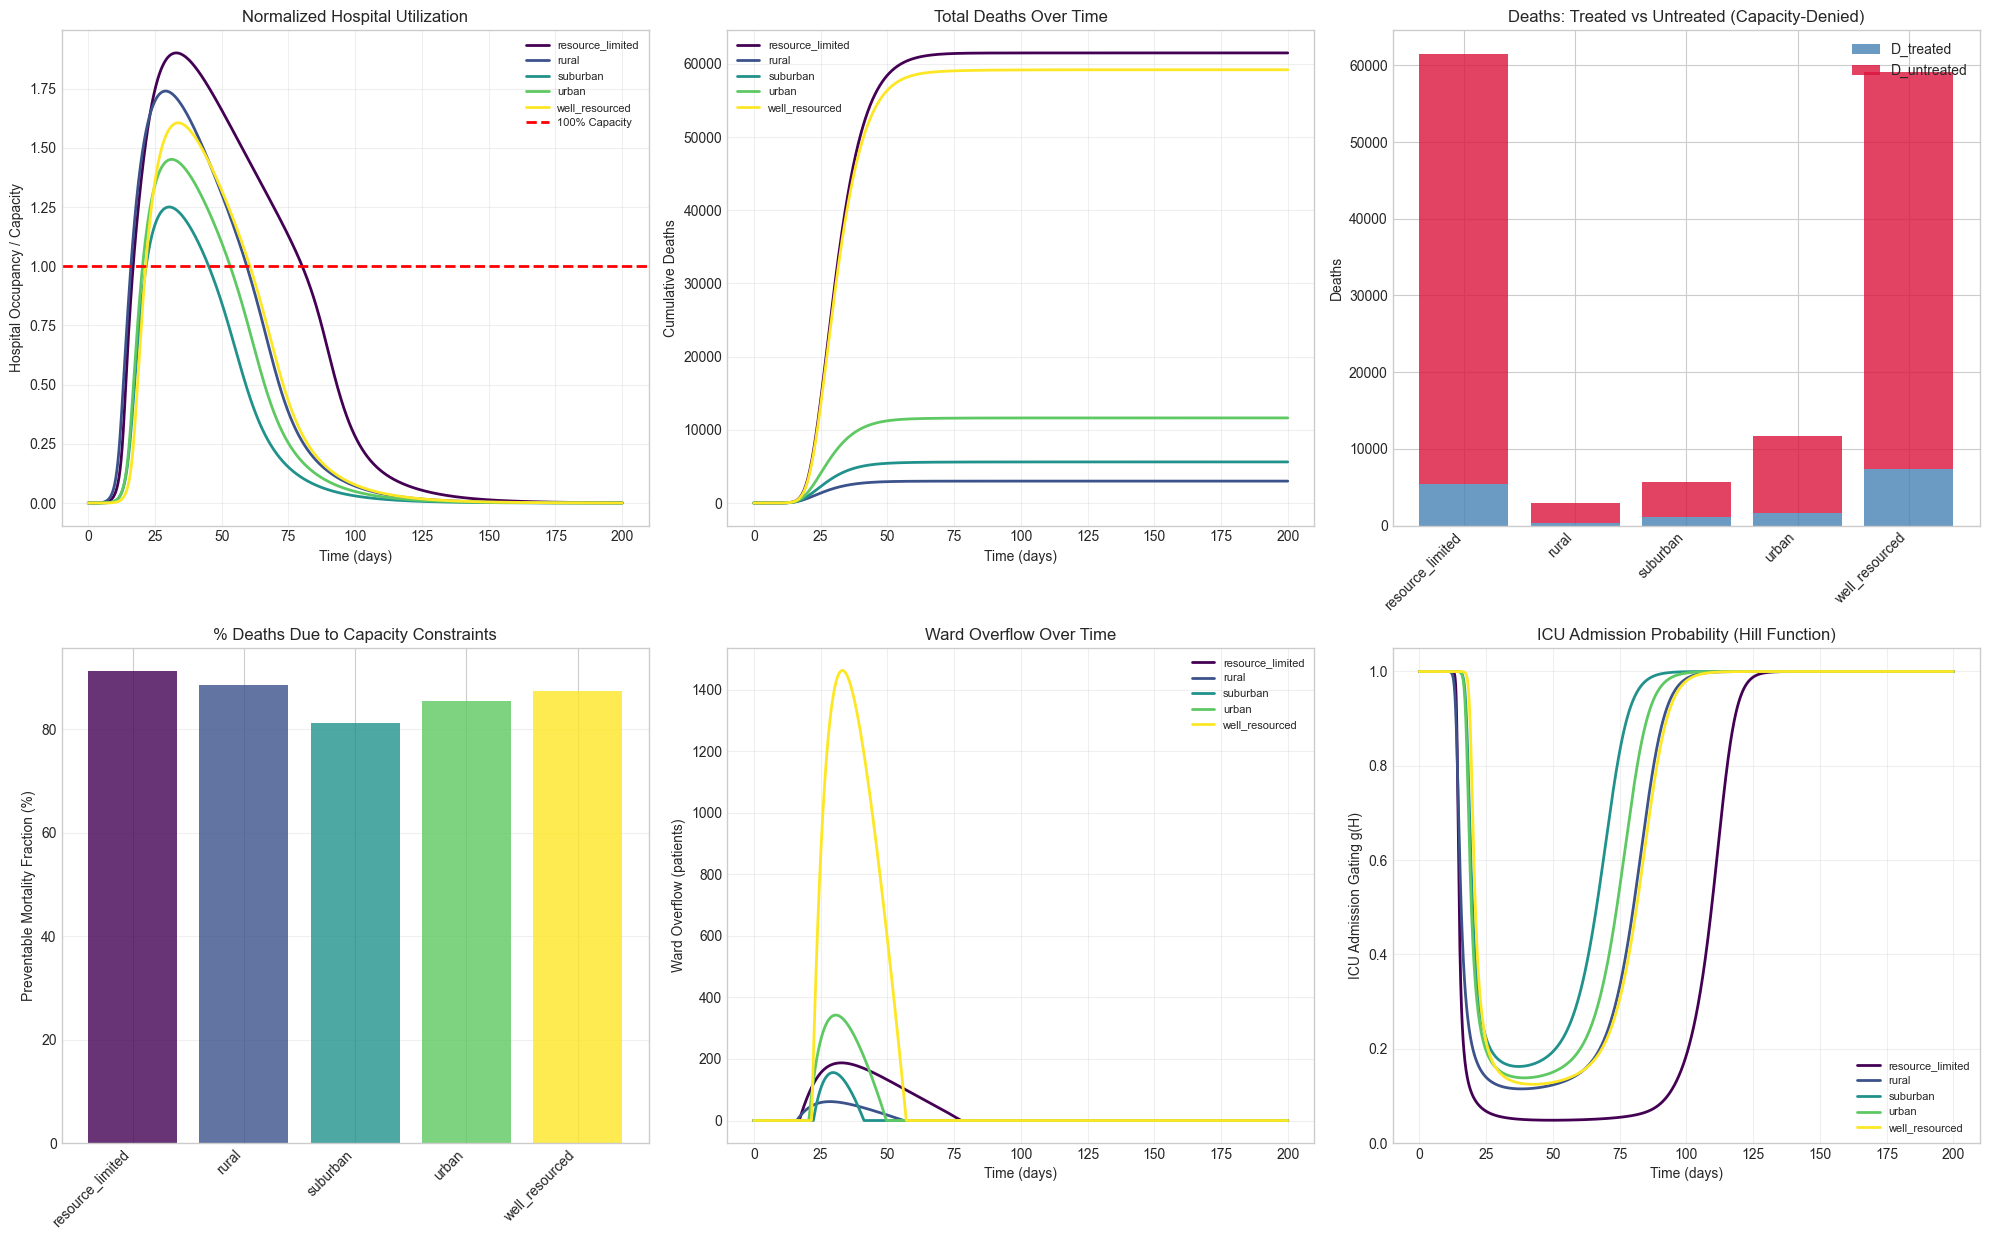


HEALTHCARE SYSTEM STRESS TEST SUMMARY
System               Population   Capacity     Deaths   Untreated%     Peak H
--------------------------------------------------------------------------------
resource_limited      2,000,000        225      61497        91.2%        428
rural                   100,000        100       2993        88.6%        174
suburban                200,000       1000       5614        81.2%       1250
urban                   400,000       1000      11627        85.4%       1452
well_resourced        2,000,000       3000      59195        87.4%       4818


In [7]:
# Visualize healthcare system comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12.5))

colors = plt.cm.viridis(np.linspace(0, 1, len(system_results)))

# Panel 1: Hospital Occupancy vs Capacity
ax1 = axes[0, 0]
for i, (name, res) in enumerate(system_results.items()):
    total_cap = res['ward_capacity'] + res['icu_capacity']
    # Normalize by capacity for comparison
    normalized_H = np.array(res['H_total']) / total_cap
    ax1.plot(res['times'], normalized_H, label=name, color=colors[i], linewidth=2)
ax1.axhline(y=1.0, color='red', linestyle='--', label='100% Capacity', linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Hospital Occupancy / Capacity')
ax1.set_title('Normalized Hospital Utilization')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: Cumulative Deaths
ax2 = axes[0, 1]
for i, (name, res) in enumerate(system_results.items()):
    ax2.plot(res['times'], res['D_total'], label=name, color=colors[i], linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Cumulative Deaths')
ax2.set_title('Total Deaths Over Time')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

# Panel 3: Treated vs Untreated Deaths (stacked area)
ax3 = axes[0, 2]
names = list(system_results.keys())
D_treated_final = [res['D_treated_total'][-1] for res in system_results.values()]
D_untreated_final = [res['D_untreated_total'][-1] for res in system_results.values()]

x = np.arange(len(names))
ax3.bar(x, D_treated_final, label='D_treated', color='steelblue', alpha=0.8)
ax3.bar(x, D_untreated_final, bottom=D_treated_final, label='D_untreated', color='crimson', alpha=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(names, rotation=45, ha='right')
ax3.set_ylabel('Deaths')
ax3.set_title('Deaths: Treated vs Untreated (Capacity-Denied)')
ax3.legend(loc='upper right')

# Panel 4: Preventable Mortality Fraction
ax4 = axes[1, 0]
pmf = [100 * D_untreated_final[i] / (D_treated_final[i] + D_untreated_final[i]) 
       if (D_treated_final[i] + D_untreated_final[i]) > 0 else 0
       for i in range(len(names))]
ax4.bar(x, pmf, color=colors, alpha=0.8)
ax4.set_xticks(x)
ax4.set_xticklabels(names, rotation=45, ha='right')
ax4.set_ylabel('Preventable Mortality Fraction (%)')
ax4.set_title('% Deaths Due to Capacity Constraints')
ax4.grid(True, alpha=0.3, axis='y')

# Panel 5: Ward Overflow
ax5 = axes[1, 1]
for i, (name, res) in enumerate(system_results.items()):
    ax5.plot(res['times'], res['ward_overflow'], label=name, color=colors[i], linewidth=2)
ax5.set_xlabel('Time (days)')
ax5.set_ylabel('Ward Overflow (patients)')
ax5.set_title('Ward Overflow Over Time')
ax5.legend(loc='upper right', fontsize=8)
ax5.grid(True, alpha=0.3)

# Panel 6: ICU Gating Factor
ax6 = axes[1, 2]
for i, (name, res) in enumerate(system_results.items()):
    ax6.plot(res['times'], res['g_icu'], label=name, color=colors[i], linewidth=2)
ax6.set_xlabel('Time (days)')
ax6.set_ylabel('ICU Admission Gating g(H)')
ax6.set_title('ICU Admission Probability (Hill Function)')
ax6.legend(loc='lower right', fontsize=8)
ax6.grid(True, alpha=0.3)
ax6.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('../results/healthcare_system_stress_test.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*80)
print("HEALTHCARE SYSTEM STRESS TEST SUMMARY")
print("="*80)
print(f"{'System':<18} {'Population':>12} {'Capacity':>10} {'Deaths':>10} {'Untreated%':>12} {'Peak H':>10}")
print("-"*80)
for i, (name, res) in enumerate(system_results.items()):
    pop = sum(res['age_pops'])
    cap = res['ward_capacity'] + res['icu_capacity']
    deaths = res['D_total'][-1]
    untreated_pct = pmf[i]
    peak = max(res['H_total'])
    print(f"{name:<18} {pop:>12,} {cap:>10} {deaths:>10.0f} {untreated_pct:>11.1f}% {peak:>10.0f}")

## Experiment 3: Intervention Timing & Strategy

### Scientific Question
*When should non-pharmaceutical interventions (NPIs) be implemented, and which strategy is most effective?*

### Mathematical Background
Policy interventions reduce transmission by a multiplier:

$$\beta_{\text{effective}}(t) = \beta_{\text{base}} \cdot (1 - r_{\text{intervention}})$$

where $r_{\text{intervention}}$ is the transmission reduction (0-1) during active intervention periods.

For overlapping interventions, the **strongest** reduction applies:
$$r_{\text{effective}} = \max(r_1, r_2, \ldots, r_n)$$

### Intervention Strategies Tested
1. **No intervention**: Baseline unmitigated epidemic
2. **Early strong**: 60% reduction starting day 14
3. **Delayed strong**: 60% reduction starting day 45
4. **Cyclical**: 50% reduction in alternating 3-week periods
5. **Tiered escalating**: Progressive 20% → 40% → 60% reduction

### Why This Matters
- **Early intervention** catches the epidemic in exponential growth phase
- **Delayed intervention** may be too late if hospital surge has already begun
- **Cyclical strategies** balance economic activity with disease control

In [8]:
# Define intervention strategies for comparison
intervention_strategies = {
    'No intervention': INTERVENTION_NONE,
    'Early strong (d14-60)': INTERVENTION_EARLY_STRONG,
    'Early moderate (d21-75)': INTERVENTION_EARLY_MODERATE,
    'Delayed strong (d45-105)': INTERVENTION_DELAYED_STRONG,
    'Cyclical (3-week on/off)': INTERVENTION_CYCLICAL,
    'Tiered escalating': INTERVENTION_TIERED_ESCALATING,
}

# Generate comparison scenarios
intervention_scenarios = create_intervention_comparison(
    base_scenario='late_onset',
    intervention_sets=intervention_strategies
)

# Run simulations
intervention_results = {}
for name, params in intervention_scenarios.items():
    print(f"Running: {name}...")
    intervention_results[name] = simulate_master_hospital_model(**params)
    
print(f"\n✓ Completed {len(intervention_results)} simulations")

Running: No intervention...
Running: Early strong (d14-60)...
Running: Early moderate (d21-75)...
Running: Delayed strong (d45-105)...
Running: Cyclical (3-week on/off)...
Running: Tiered escalating...

✓ Completed 6 simulations


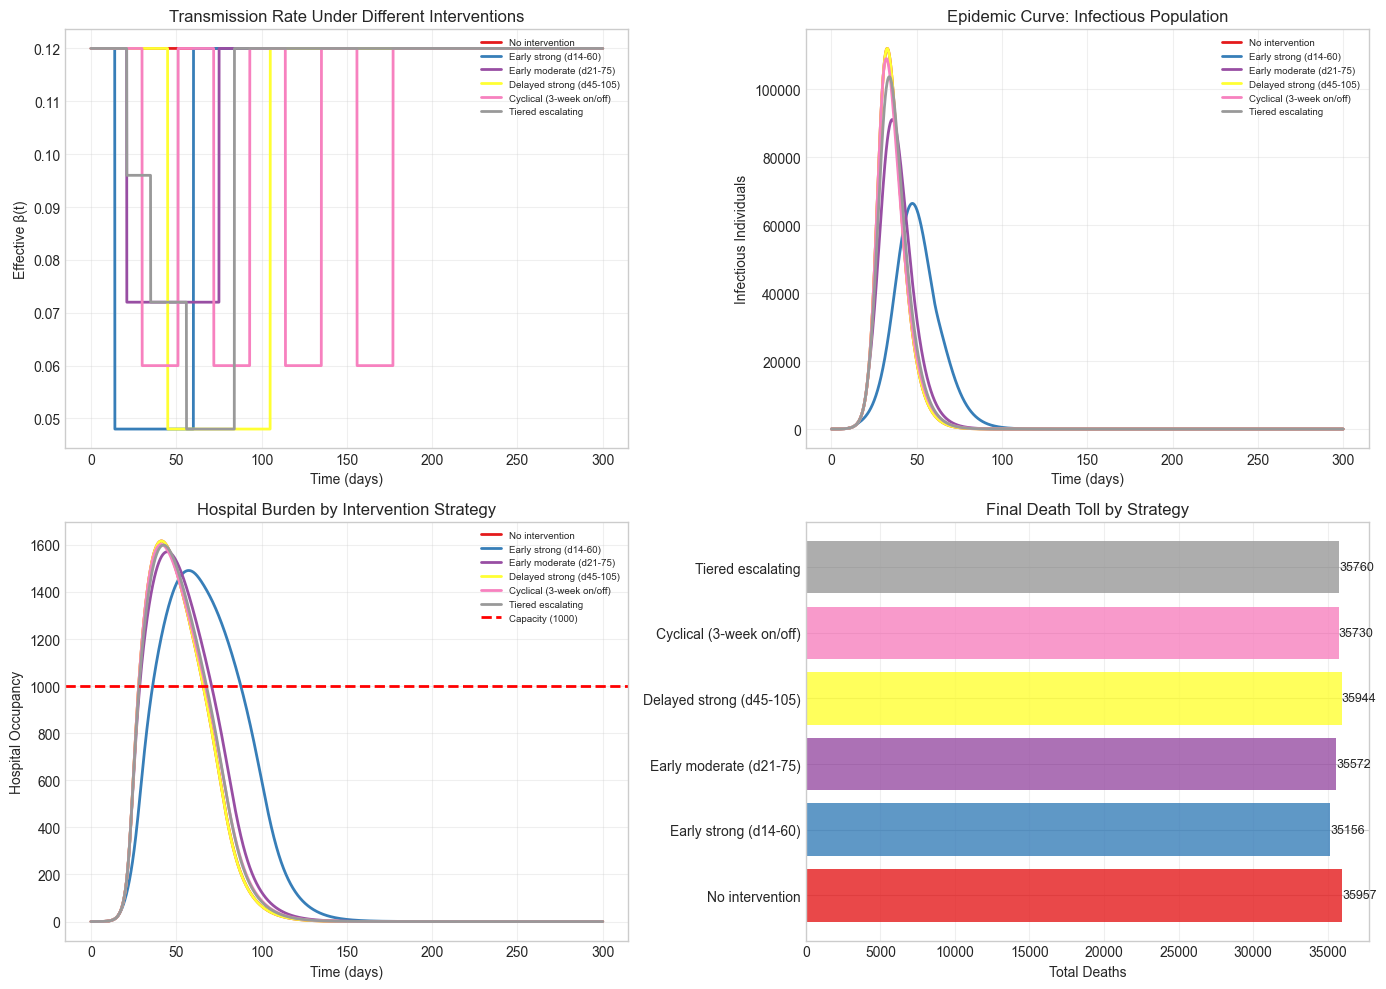


INTERVENTION STRATEGY COMPARISON
Strategy                         Deaths       Peak I     Peak H   Days>Cap
--------------------------------------------------------------------------------
No intervention                   35957       112068       1617        379
Early strong (d14-60)             35156        66437       1491        517
Early moderate (d21-75)           35572        91144       1571        422
Delayed strong (d45-105)          35944       112068       1617        379
Cyclical (3-week on/off)          35730       109073       1602        391
Tiered escalating                 35760       103737       1599        395


In [9]:
# Visualize intervention comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.Set1(np.linspace(0, 1, len(intervention_results)))

# Panel 1: Transmission Rate β(t) Over Time
ax1 = axes[0, 0]
for i, (name, res) in enumerate(intervention_results.items()):
    ax1.plot(res['times'], res['beta_t'], label=name, color=colors[i], linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Effective β(t)')
ax1.set_title('Transmission Rate Under Different Interventions')
ax1.legend(loc='upper right', fontsize=7)
ax1.grid(True, alpha=0.3)

# Panel 2: Infected Population I(t)
ax2 = axes[0, 1]
for i, (name, res) in enumerate(intervention_results.items()):
    ax2.plot(res['times'], res['I_total'], label=name, color=colors[i], linewidth=2)
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Infectious Individuals')
ax2.set_title('Epidemic Curve: Infectious Population')
ax2.legend(loc='upper right', fontsize=7)
ax2.grid(True, alpha=0.3)

# Panel 3: Hospital Occupancy
ax3 = axes[1, 0]
for i, (name, res) in enumerate(intervention_results.items()):
    ax3.plot(res['times'], res['H_total'], label=name, color=colors[i], linewidth=2)
total_cap = res['ward_capacity'] + res['icu_capacity']
ax3.axhline(y=total_cap, color='red', linestyle='--', linewidth=2, label=f'Capacity ({total_cap})')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Hospital Occupancy')
ax3.set_title('Hospital Burden by Intervention Strategy')
ax3.legend(loc='upper right', fontsize=7)
ax3.grid(True, alpha=0.3)

# Panel 4: Summary Bar Chart - Deaths
ax4 = axes[1, 1]
names = list(intervention_results.keys())
final_deaths = [res['D_total'][-1] for res in intervention_results.values()]
peak_I = [max(res['I_total']) for res in intervention_results.values()]

x = np.arange(len(names))
bars = ax4.barh(x, final_deaths, color=colors, alpha=0.8)
ax4.set_yticks(x)
ax4.set_yticklabels(names)
ax4.set_xlabel('Total Deaths')
ax4.set_title('Final Death Toll by Strategy')
ax4.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, deaths) in enumerate(zip(bars, final_deaths)):
    ax4.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
             f'{deaths:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/intervention_timing_and_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*80)
print("INTERVENTION STRATEGY COMPARISON")
print("="*80)
print(f"{'Strategy':<28} {'Deaths':>10} {'Peak I':>12} {'Peak H':>10} {'Days>Cap':>10}")
print("-"*80)
for name, res in intervention_results.items():
    deaths = res['D_total'][-1]
    peak_i = max(res['I_total'])
    peak_h = max(res['H_total'])
    cap = res['ward_capacity'] + res['icu_capacity']
    days_over = sum(1 for h in res['H_total'] if h > cap)
    print(f"{name:<28} {deaths:>10.0f} {peak_i:>12.0f} {peak_h:>10.0f} {days_over:>10}")

## Experiment 4: Transmission Rate Sensitivity ($\beta$ Sweeps)

### Scientific Question
*How sensitive are outcomes to the basic reproduction number $R_0$?*

### Mathematical Background
The basic reproduction number is approximately:

$$R_0 \approx \beta \cdot \bar{c} \cdot \frac{1}{\gamma + \mu}$$

where:
- $\beta$ = transmission probability per contact
- $\bar{c}$ = average contact rate (from contact matrix)
- $\gamma$ = recovery rate
- $\mu$ = mortality rate

Higher $R_0$ leads to:
- **Faster epidemic growth** in early phase
- **Higher attack rate** (final fraction infected)
- **Greater hospital burden** (more severe cases simultaneously)

### Why This Matters
Pathogens vary dramatically in transmissibility:
| Pathogen | Approximate $R_0$ |
|----------|------------------|
| Seasonal flu | 1.0-1.5 |
| COVID-19 (original) | 2.0-3.0 |
| COVID-19 (Delta) | 5.0-6.0 |
| Measles | 12-18 |

Understanding this sensitivity helps prepare for future pathogens with unknown characteristics.

In [10]:
# Beta sensitivity analysis
beta_values = [0.015, 0.020, 0.028, 0.038, 0.045, 0.055, 0.065, 0.075, 0.085, 0.095]
beta_labels = ['R0≈1.3', 'R0≈1.8', 'R0≈2.5', 'R0≈3.5', 'R0≈4.5', 'R0≈6.0', 'R0≈7.0', 'R0≈8.0', 'R0≈9.0', 'R0≈10.0']

beta_scenarios = create_sensitivity_variants(
    base_scenario='baseline',
    parameter='beta_base',
    values=beta_values,
    labels=beta_labels
)

# Run simulations
beta_results = {}
for name, params in beta_scenarios.items():
    print(f"Running: {name} (β={params['beta_base']:.2f})...")
    beta_results[name] = simulate_master_hospital_model(**params)
    
print(f"\n✓ Completed {len(beta_results)} simulations")

Running: R0≈1.3 (β=0.01)...
Running: R0≈1.8 (β=0.02)...
Running: R0≈2.5 (β=0.03)...
Running: R0≈3.5 (β=0.04)...
Running: R0≈4.5 (β=0.04)...
Running: R0≈6.0 (β=0.06)...
Running: R0≈7.0 (β=0.07)...
Running: R0≈8.0 (β=0.07)...
Running: R0≈9.0 (β=0.09)...
Running: R0≈10.0 (β=0.10)...

✓ Completed 10 simulations


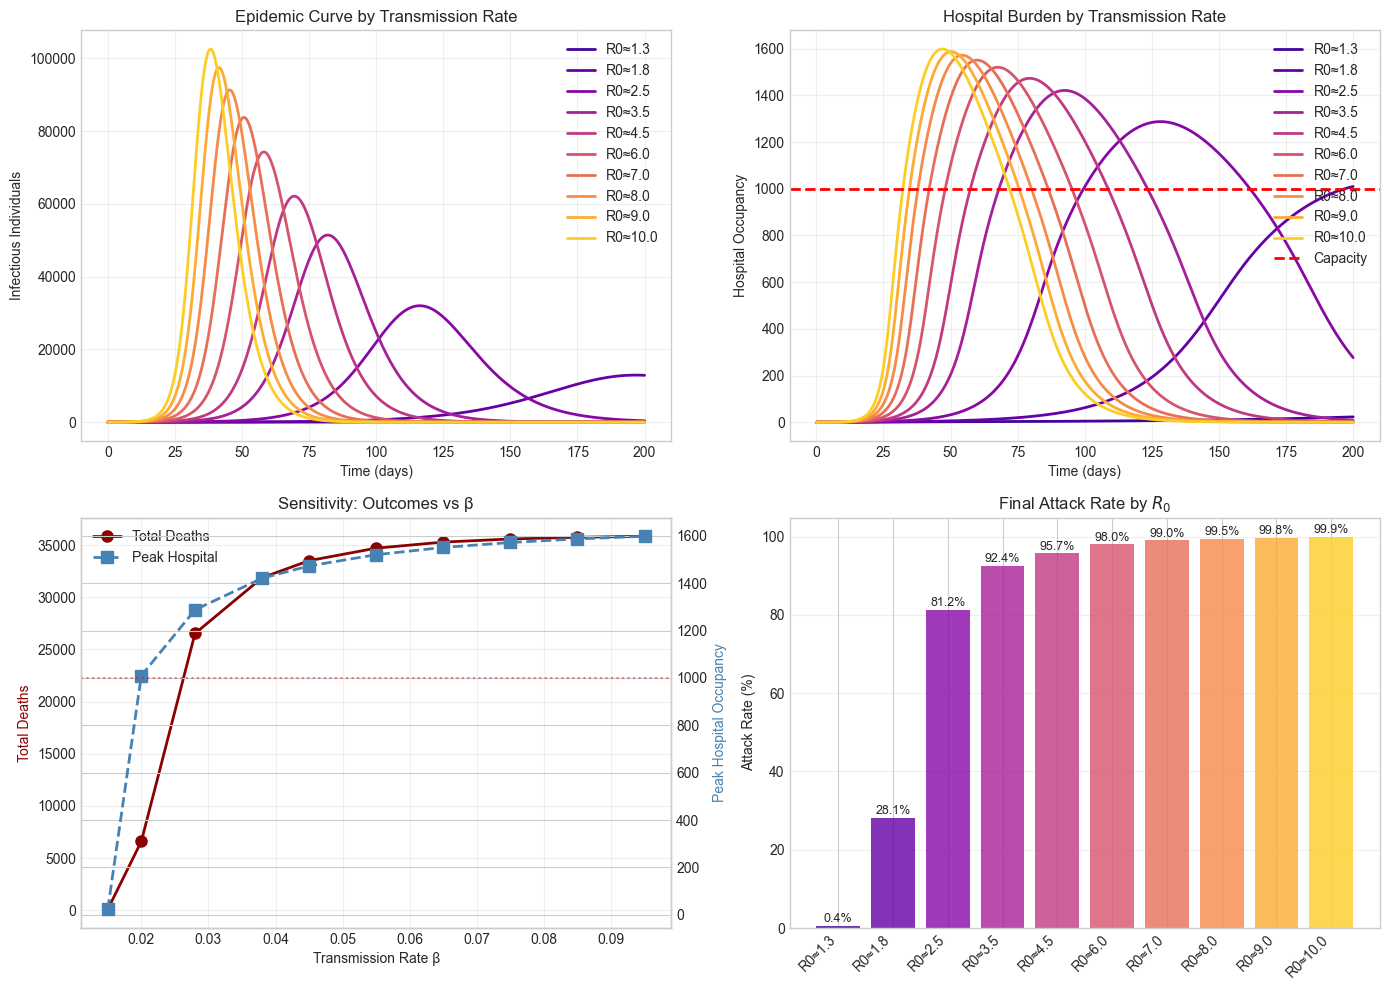


TRANSMISSION SENSITIVITY SUMMARY
R0 (approx)         β       Deaths       Peak H     Attack %
----------------------------------------------------------------------
R0≈1.3           0.01           88           23         0.4%
R0≈1.8           0.02         6599         1010        28.1%
R0≈2.5           0.03        26527         1288        81.2%
R0≈3.5           0.04        31871         1421        92.4%
R0≈4.5           0.04        33507         1473        95.7%
R0≈6.0           0.06        34705         1520        98.0%
R0≈7.0           0.07        35285         1551        99.0%
R0≈8.0           0.07        35585         1572        99.5%
R0≈9.0           0.09        35750         1587        99.8%
R0≈10.0          0.10        35845         1598        99.9%


In [11]:
# Visualize beta sensitivity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(beta_results)))

# Panel 1: Epidemic curves (I)
ax1 = axes[0, 0]
for i, (name, res) in enumerate(beta_results.items()):
    ax1.plot(res['times'], res['I_total'], label=name, color=colors[i], linewidth=2)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Infectious Individuals')
ax1.set_title('Epidemic Curve by Transmission Rate')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Panel 2: Hospital curves
ax2 = axes[0, 1]
for i, (name, res) in enumerate(beta_results.items()):
    ax2.plot(res['times'], res['H_total'], label=name, color=colors[i], linewidth=2)
total_cap = res['ward_capacity'] + res['icu_capacity']
ax2.axhline(y=total_cap, color='red', linestyle='--', linewidth=2, label='Capacity')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Hospital Occupancy')
ax2.set_title('Hospital Burden by Transmission Rate')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Panel 3: Final outcomes vs beta
ax3 = axes[1, 0]
betas = beta_values
final_deaths = [beta_results[label]['D_total'][-1] for label in beta_labels]
peak_H = [max(beta_results[label]['H_total']) for label in beta_labels]

ax3.plot(betas, final_deaths, 'o-', color='darkred', linewidth=2, markersize=8, label='Total Deaths')
ax3_twin = ax3.twinx()
ax3_twin.plot(betas, peak_H, 's--', color='steelblue', linewidth=2, markersize=8, label='Peak Hospital')
ax3_twin.axhline(y=total_cap, color='red', linestyle=':', alpha=0.5)

ax3.set_xlabel('Transmission Rate β')
ax3.set_ylabel('Total Deaths', color='darkred')
ax3_twin.set_ylabel('Peak Hospital Occupancy', color='steelblue')
ax3.set_title('Sensitivity: Outcomes vs β')
ax3.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Panel 4: Attack rate vs beta
ax4 = axes[1, 1]
attack_rates = []
for label in beta_labels:
    res = beta_results[label]
    # Attack rate = (R + D) / N at end
    total_pop = sum(res['age_pops'])
    # Sum final R and D across all ages
    final_R = sum(res['R'][a][-1] for a in range(len(res['age_pops'])))
    final_R_vax = sum(res['R_vax'][a][-1] for a in range(len(res['age_pops'])))
    final_D = res['D_total'][-1]
    attack_rate = 100 * (final_R + final_R_vax + final_D) / total_pop
    attack_rates.append(attack_rate)

ax4.bar(range(len(beta_labels)), attack_rates, color=colors, alpha=0.8)
ax4.set_xticks(range(len(beta_labels)))
ax4.set_xticklabels(beta_labels, rotation=45, ha='right')
ax4.set_ylabel('Attack Rate (%)')
ax4.set_title('Final Attack Rate by $R_0$')
ax4.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for i, rate in enumerate(attack_rates):
    ax4.text(i, rate + 1, f'{rate:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/transmission_rate_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("TRANSMISSION SENSITIVITY SUMMARY")
print("="*70)
print(f"{'R0 (approx)':<12} {'β':>8} {'Deaths':>12} {'Peak H':>12} {'Attack %':>12}")
print("-"*70)
for i, (label, beta) in enumerate(zip(beta_labels, betas)):
    res = beta_results[label]
    deaths = res['D_total'][-1]
    peak = max(res['H_total'])
    ar = attack_rates[i]
    print(f"{label:<12} {beta:>8.2f} {deaths:>12.0f} {peak:>12.0f} {ar:>11.1f}%")

## Experiment 5: Capacity Threshold Analysis

### Scientific Question
*At what capacity level does the healthcare system become overwhelmed, and how does this affect mortality?*

### Mathematical Background
The relationship between capacity and mortality is **nonlinear** due to Hill function gating. Define:

$$\text{Effective Capacity Ratio} = \frac{K_{\text{beds}}}{\text{Peak Demand}}$$

When this ratio drops below 1, excess mortality rises dramatically. The marginal benefit of additional capacity follows:

$$\frac{\partial D}{\partial K} \propto -\left(\frac{H}{K}\right)^{n-1} \cdot \frac{1}{\left(1 + (H/K)^n\right)^2}$$

This derivative is largest when $H \approx K$, meaning **adding capacity is most valuable near the tipping point**.

### Why This Matters
- Informs **surge capacity planning** decisions
- Identifies **critical thresholds** for triggering field hospitals
- Quantifies **return on investment** for healthcare infrastructure

In [12]:
# Capacity sensitivity analysis - vary ward capacity
# Keep ward:ICU ratio approximately constant (80:20)
capacity_multipliers = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0]
base_ward = 400
base_icu = 100

capacity_results = {}
for mult in capacity_multipliers:
    ward_cap = int(base_ward * mult)
    icu_cap = int(base_icu * mult)
    label = f"{mult:.0%} capacity"
    
    params = get_scenario_params('baseline', validate=False)
    params['capacity_config']['ward'] = ward_cap
    params['capacity_config']['icu'] = icu_cap
    params['track_differential_mortality'] = True
    
    print(f"Running: {label} (ward={ward_cap}, icu={icu_cap})...")
    capacity_results[label] = simulate_master_hospital_model(**params)

print(f"\n✓ Completed {len(capacity_results)} simulations")

Running: 25% capacity (ward=100, icu=25)...
Running: 50% capacity (ward=200, icu=50)...
Running: 75% capacity (ward=300, icu=75)...
Running: 100% capacity (ward=400, icu=100)...
Running: 125% capacity (ward=500, icu=125)...
Running: 150% capacity (ward=600, icu=150)...
Running: 200% capacity (ward=800, icu=200)...
Running: 300% capacity (ward=1200, icu=300)...

✓ Completed 8 simulations


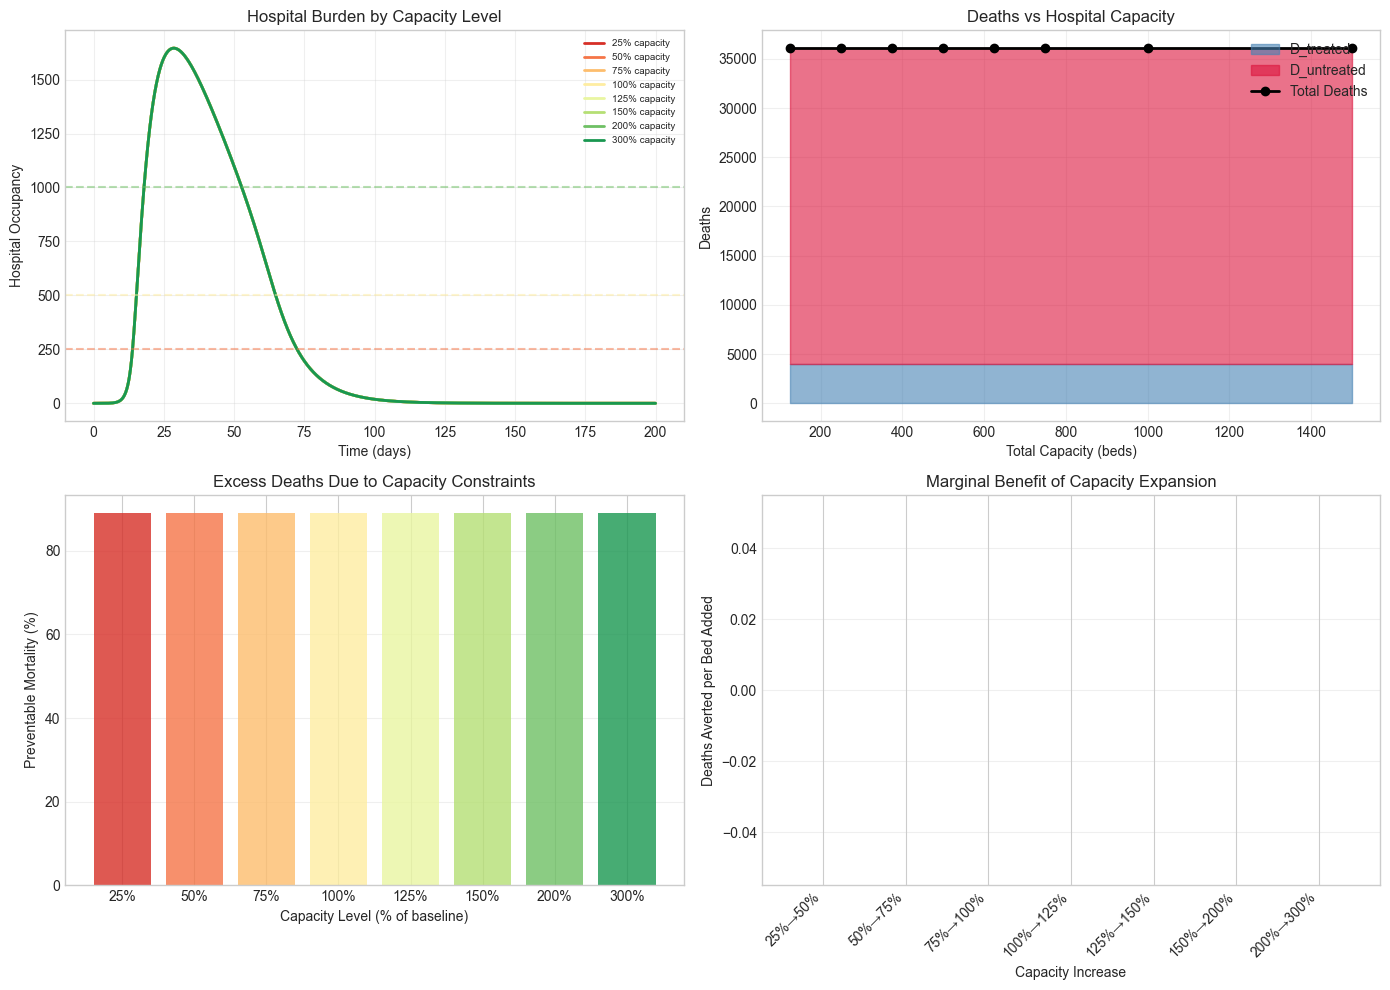


CAPACITY THRESHOLD ANALYSIS SUMMARY
    Capacity       Beds     Deaths  Untreated       PMF%
----------------------------------------------------------------------
25% capacity      125.0      36087      32073      88.9%
50% capacity      250.0      36087      32073      88.9%
75% capacity      375.0      36087      32073      88.9%
100% capacity      500.0      36087      32073      88.9%
125% capacity      625.0      36087      32073      88.9%
150% capacity      750.0      36087      32073      88.9%
200% capacity     1000.0      36087      32073      88.9%
300% capacity     1500.0      36087      32073      88.9%


In [13]:
# Visualize capacity threshold analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(capacity_results)))

# Panel 1: Hospital occupancy time series
ax1 = axes[0, 0]
for i, (label, res) in enumerate(capacity_results.items()):
    ax1.plot(res['times'], res['H_total'], label=label, color=colors[i], linewidth=2)
# Show capacity lines for a few key levels
for i, mult in enumerate([0.5, 1.0, 2.0]):
    cap = base_ward * mult + base_icu * mult
    ax1.axhline(y=cap, color=colors[capacity_multipliers.index(mult)], 
                linestyle='--', alpha=0.5)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Hospital Occupancy')
ax1.set_title('Hospital Burden by Capacity Level')
ax1.legend(loc='upper right', fontsize=7)
ax1.grid(True, alpha=0.3)

# Panel 2: Deaths vs Capacity
ax2 = axes[0, 1]
total_caps = [(base_ward + base_icu) * m for m in capacity_multipliers]
deaths = [res['D_total'][-1] for res in capacity_results.values()]
untreated = [res['D_untreated_total'][-1] for res in capacity_results.values()]
treated = [res['D_treated_total'][-1] for res in capacity_results.values()]

ax2.fill_between(total_caps, 0, treated, alpha=0.6, label='D_treated', color='steelblue')
ax2.fill_between(total_caps, treated, deaths, alpha=0.6, label='D_untreated', color='crimson')
ax2.plot(total_caps, deaths, 'ko-', markersize=6, linewidth=2, label='Total Deaths')
ax2.set_xlabel('Total Capacity (beds)')
ax2.set_ylabel('Deaths')
ax2.set_title('Deaths vs Hospital Capacity')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Panel 3: Preventable Mortality Fraction
ax3 = axes[1, 0]
pmf = [100 * u / d if d > 0 else 0 for u, d in zip(untreated, deaths)]
ax3.bar(range(len(capacity_multipliers)), pmf, color=colors, alpha=0.8)
ax3.set_xticks(range(len(capacity_multipliers)))
ax3.set_xticklabels([f"{m:.0%}" for m in capacity_multipliers])
ax3.set_xlabel('Capacity Level (% of baseline)')
ax3.set_ylabel('Preventable Mortality (%)')
ax3.set_title('Excess Deaths Due to Capacity Constraints')
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Marginal benefit of capacity
ax4 = axes[1, 1]
# Calculate marginal deaths averted per additional bed
marginal_benefit = []
for i in range(1, len(deaths)):
    beds_added = total_caps[i] - total_caps[i-1]
    deaths_averted = deaths[i-1] - deaths[i]
    marginal_benefit.append(deaths_averted / beds_added if beds_added > 0 else 0)

x_labels = [f"{capacity_multipliers[i-1]:.0%}→{capacity_multipliers[i]:.0%}" 
            for i in range(1, len(capacity_multipliers))]
bars = ax4.bar(range(len(marginal_benefit)), marginal_benefit, 
               color=plt.cm.Blues(np.linspace(0.3, 0.9, len(marginal_benefit))), alpha=0.8)
ax4.set_xticks(range(len(marginal_benefit)))
ax4.set_xticklabels(x_labels, rotation=45, ha='right')
ax4.set_xlabel('Capacity Increase')
ax4.set_ylabel('Deaths Averted per Bed Added')
ax4.set_title('Marginal Benefit of Capacity Expansion')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../results/capacity_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n" + "="*70)
print("CAPACITY THRESHOLD ANALYSIS SUMMARY")
print("="*70)
print(f"{'Capacity':>12} {'Beds':>10} {'Deaths':>10} {'Untreated':>10} {'PMF%':>10}")
print("-"*70)
for i, (label, res) in enumerate(capacity_results.items()):
    beds = total_caps[i]
    d = deaths[i]
    u = untreated[i]
    p = pmf[i]
    print(f"{label:>12} {beds:>10} {d:>10.0f} {u:>10.0f} {p:>9.1f}%")

## Experiment 6: Endemic Equilibrium Dynamics

### Scientific Question
*How do waning immunity and seasonal forcing interact to produce recurring epidemic waves?*

### Mathematical Background
For endemic dynamics, we include immunity waning:

$$\frac{dR}{dt} = \gamma_I I + \gamma_X X + \gamma_H H - \omega R$$

$$\frac{dS}{dt} = \ldots + \omega R$$

where $\omega$ is the waning rate (mean duration of immunity = $1/\omega$).

Seasonal forcing modulates transmission:
$$\beta(t) = \beta_{\text{base}} \left[1 + A \cos\left(\frac{2\pi(t - t_{\text{peak}})}{T}\right)\right]$$

where:
- $A$ = seasonal amplitude (0-1)
- $T$ = period (typically 365 days)
- $t_{\text{peak}}$ = day of peak transmission (winter)

### Endemic Equilibrium Condition
For stable endemicity, we need:
$$R_0 > 1 + \frac{\omega}{\mu_{\text{eff}}}$$

Below this threshold, the pathogen may fade out between waves.

### Why This Matters
- Models **seasonal influenza patterns**
- Predicts **endemic COVID-19 scenarios**
- Informs **annual vaccination campaigns**

In [14]:
# Experiment 6: Endemic dynamics with seasonal forcing

def run_endemic_scenario(immunity_duration_days, seasonal_amplitude, years=3):
    """
    Simulate endemic dynamics with waning immunity and seasonal forcing.
    
    Parameters:
    -----------
    immunity_duration_days : float
        Mean duration of immunity (days)
    seasonal_amplitude : float
        Amplitude of seasonal forcing (0-1)
    years : int
        Number of years to simulate
    """
    omega = 1.0 / immunity_duration_days if immunity_duration_days > 0 else 0
    
    # Create simulation length
    days = int(365 * years)
    
    # Get base parameters from endemic scenario
    scenario_params = get_scenario_params('endemic_vaccination').copy()
    
    # Set waning parameters using the correct parameter format
    scenario_params['waning_config'] = {'omega': omega}
    
    # Set seasonal forcing using seasonal_params
    scenario_params['seasonal_config'] = {
        'amplitude': seasonal_amplitude,  # 30% seasonal variation
        'period': 365,                     # Annual cycle
        'peak_day': 0                      # Peak at day 0 (winter)
    }
    
    scenario_params['seasonal_config']['days'] = days
    
    return simulate_master_hospital_model(**scenario_params)

# Compare different immunity durations
immunity_durations = [180, 365, 730]  # 6 months, 1 year, 2 years
seasonal_amp = 0.3  # 30% seasonal variation

print("Simulating endemic scenarios with varying immunity duration...")
endemic_results = {}

for duration in immunity_durations:
    print(f"  Immunity duration: {duration} days...")
    result = run_endemic_scenario(duration, seasonal_amp, years=3)
    endemic_results[f'{duration}d immunity'] = result

print("✓ Endemic simulations complete")

Simulating endemic scenarios with varying immunity duration...
  Immunity duration: 180 days...
  Immunity duration: 365 days...
  Immunity duration: 730 days...
✓ Endemic simulations complete


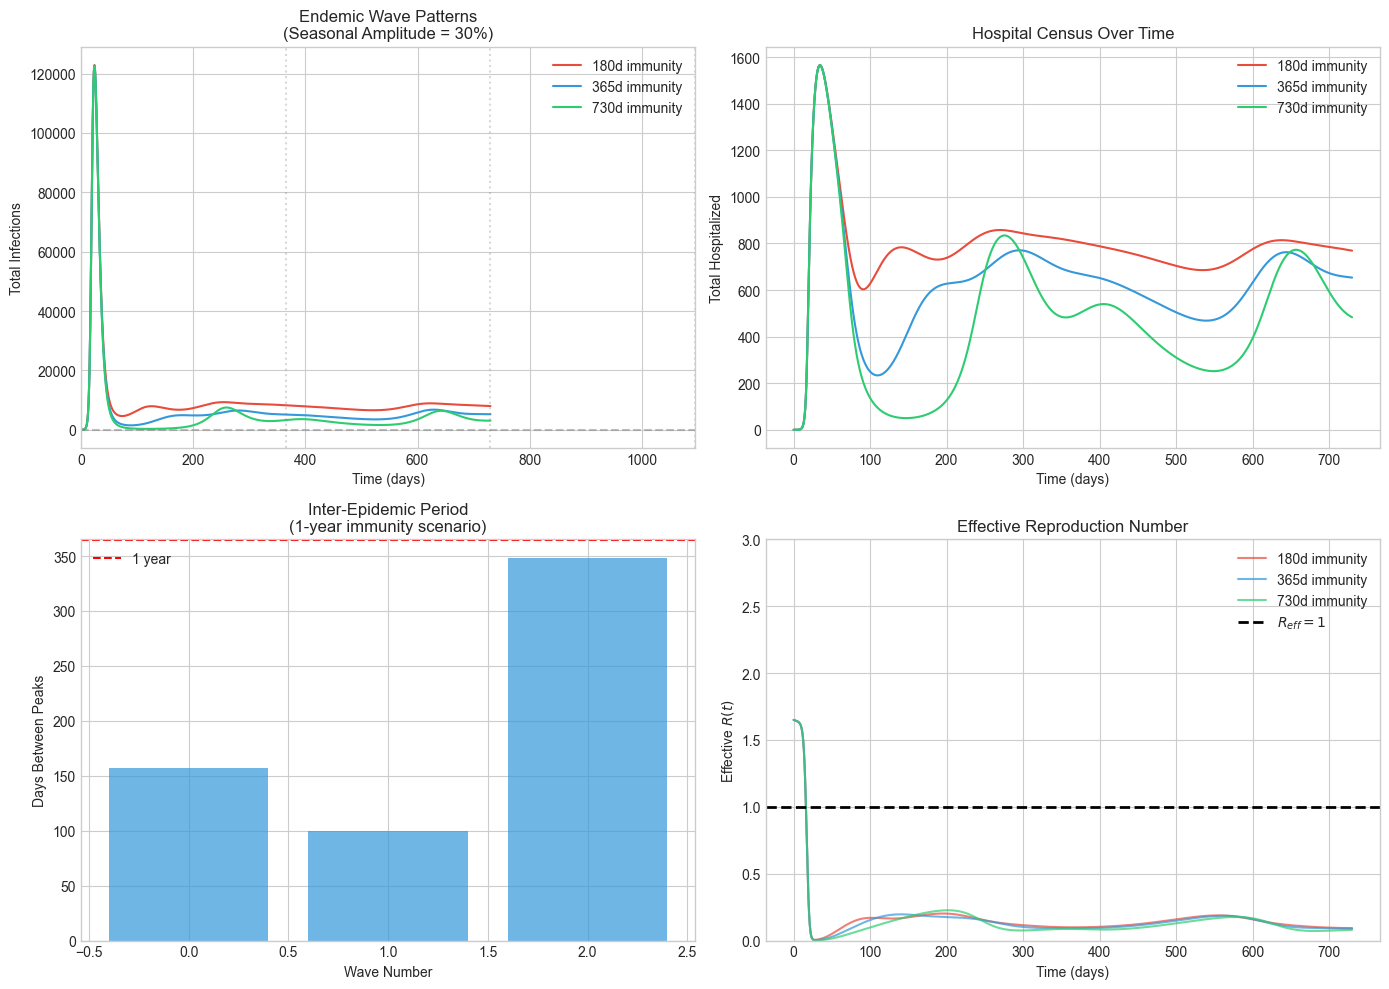


📊 Key Observations:
- Shorter immunity duration → more frequent epidemic waves
- Seasonal forcing synchronizes waves with winter peaks
- R_eff oscillates around 1 in endemic equilibrium


In [15]:
# Visualize endemic wave patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Infections over time for each immunity duration
ax1 = axes[0, 0]
colors = ['#e74c3c', '#3498db', '#2ecc71']
for (label, result), color in zip(endemic_results.items(), colors):
    t = result['times']
    # Sum infected across age groups (using I_total which is already aggregated)
    I_total = result['I_total']
    ax1.plot(t, I_total, label=label, color=color, linewidth=1.5)

ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Total Infections')
ax1.set_title('Endemic Wave Patterns\n(Seasonal Amplitude = 30%)')
ax1.legend()
ax1.set_xlim(0, 365*3)

# Add year markers
for year in range(1, 4):
    ax1.axvline(x=year*365, color='gray', linestyle=':', alpha=0.3)

# Plot 2: Hospital burden
ax2 = axes[0, 1]
for (label, result), color in zip(endemic_results.items(), colors):
    t = result['times']
    H_total = result['H_total']
    ax2.plot(t, H_total, label=label, color=color, linewidth=1.5)

ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Total Hospitalized')
ax2.set_title('Hospital Census Over Time')
ax2.legend()

# Plot 3: Inter-epidemic period analysis
ax3 = axes[1, 0]
# Analyze peak timing for the 1-year immunity scenario
t = list(endemic_results.values())[1]['times']
I_1yr = list(endemic_results.values())[1]['I_total']

from scipy.signal import find_peaks
peaks, _ = find_peaks(I_1yr, height=100, distance=100)

if len(peaks) > 1:
    inter_epidemic_days = np.diff([t[p] for p in peaks])
    ax3.bar(range(len(inter_epidemic_days)), inter_epidemic_days, color='#3498db', alpha=0.7)
    ax3.axhline(y=365, color='red', linestyle='--', label='1 year')
    ax3.set_xlabel('Wave Number')
    ax3.set_ylabel('Days Between Peaks')
    ax3.set_title('Inter-Epidemic Period\n(1-year immunity scenario)')
    ax3.legend()
else:
    ax3.text(0.5, 0.5, 'Insufficient peaks detected\n(epidemic may have faded out)', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=12)
    ax3.set_title('Inter-Epidemic Period\n(1-year immunity scenario)')

# Plot 4: Effective R(t) over time
ax4 = axes[1, 1]
# Compute effective R from susceptible depletion
for (label, result), color in zip(endemic_results.items(), colors):
    t = result['times']
    # Get total susceptibles - S is list of arrays, need to sum element-wise
    S_arrays = result['S']  # List of arrays, one per age group
    S_total = np.zeros_like(t)
    for S_age in S_arrays:
        S_total = S_total + np.array(S_age)
    
    N_total = sum(result['age_pops'])
    S_frac = S_total / N_total
    
    # Approximate R_eff = R0 * S(t)/N
    base_params = get_scenario_params('endemic_vaccination')
    R0 = base_params.get('R0', 2.5)
    R_eff = R0 * S_frac
    ax4.plot(t, R_eff, label=label, color=color, linewidth=1.5, alpha=0.7)

ax4.axhline(y=1, color='black', linestyle='--', linewidth=2, label=r'$R_{eff} = 1$')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel(r'Effective $R(t)$')
ax4.set_title('Effective Reproduction Number')
ax4.legend()
ax4.set_ylim(0, 3)

plt.tight_layout()
plt.savefig('../results/endemic_equilibrium_dynamics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Key Observations:")
print("- Shorter immunity duration → more frequent epidemic waves")
print("- Seasonal forcing synchronizes waves with winter peaks")
print("- R_eff oscillates around 1 in endemic equilibrium")

## Experiment 7: Age-Structured Epidemic Dynamics

### Scientific Question
*How does age-specific contact structure and vulnerability shape epidemic outcomes?*

### Mathematical Background
The force of infection for age group $a$ depends on contact with all age groups:

$$\lambda_a(t) = \beta(t) \sum_{b} C_{ab} \frac{I_b(t)}{N_b}$$

where $C_{ab}$ is the contact matrix element for contacts from age group $a$ to $b$.

### Contact Matrix Structure
Typical contact patterns show:
1. **High within-group mixing** (diagonal elements)
2. **Child-parent contact** (young ↔ middle-aged)
3. **Lower elderly mixing** (except with caregivers)

The **dominant eigenvalue** of the Next Generation Matrix determines $R_0$:
$$R_0 = \rho\left(\frac{\beta}{\gamma} \mathbf{C} \cdot \text{diag}\left(\frac{1}{N_1}, \ldots, \frac{1}{N_k}\right)\right)$$

### Clinical Importance
Age-specific severity ($\sigma_a$) and mortality ($\mu_a$) capture:
- **Immunosenescence** in elderly
- **Higher hospitalization risk** with age
- **Lower severity** in young (typically)

In [16]:
# Experiment 7: Age-structured contact analysis

# Define different contact scenarios
def create_contact_matrix(scenario):
    """
    Create contact matrices representing different social structures.
    Age groups: Young (0-19), Middle (20-64), Elderly (65+)
    """
    if scenario == 'baseline':
        # Standard mixing with age assortivity
        return np.array([
            [8.0, 4.0, 1.5],   # Young contacts with Y, M, E
            [4.0, 6.0, 2.0],   # Middle contacts
            [1.5, 2.0, 3.0]    # Elderly contacts
        ])
    elif scenario == 'schools_closed':
        # Reduced young-young contact (school closure)
        return np.array([
            [3.0, 3.5, 1.5],   # Reduced school mixing
            [3.5, 6.0, 2.0],   # Slightly reduced from young
            [1.5, 2.0, 3.0]    # Elderly unchanged
        ])
    elif scenario == 'elderly_isolated':
        # Shielding strategy for elderly
        return np.array([
            [8.0, 4.0, 0.5],   # Minimal contact with elderly
            [4.0, 6.0, 0.5],   # Minimal contact with elderly
            [0.5, 0.5, 1.0]    # Severely reduced elderly mixing
        ])
    elif scenario == 'homogeneous':
        # Proportionate mixing (theoretical)
        return np.array([
            [5.0, 5.0, 5.0],
            [5.0, 5.0, 5.0],
            [5.0, 5.0, 5.0]
        ])
    else:
        raise ValueError(f"Unknown scenario: {scenario}")

# Run simulations with different contact structures
contact_scenarios = ['baseline', 'schools_closed', 'elderly_isolated', 'homogeneous']
age_results = {}

base_params = get_scenario_params('covid_delta')
print("Running age-structured contact experiments...")

for scenario in contact_scenarios:
    print(f"  Contact scenario: {scenario}")
    C = create_contact_matrix(scenario)
    
    params = base_params.copy()
    params['contact_matrix'] = C
    params['demographic_config'] = DEMOGRAPHIC_PARAMS_DEFAULT
    
    result = simulate_master_hospital_model(**params)
    
    # Estimate R0 from spectral radius of next-generation matrix
    # Using mean gamma from age_params
    mean_gamma = np.mean([ap.get('gamma_I', 0.1) for ap in params['age_params']])
    spectral_radius = np.real(np.max(np.linalg.eigvals(C)))
    
    age_results[scenario] = {
        'result': result,
        'contact_matrix': C,
        'R0_estimate': spectral_radius * params['beta_base'] / mean_gamma
    }

print("✓ Age-structured simulations complete")

Running age-structured contact experiments...
  Contact scenario: baseline
  Contact scenario: schools_closed
  Contact scenario: elderly_isolated
  Contact scenario: homogeneous
✓ Age-structured simulations complete


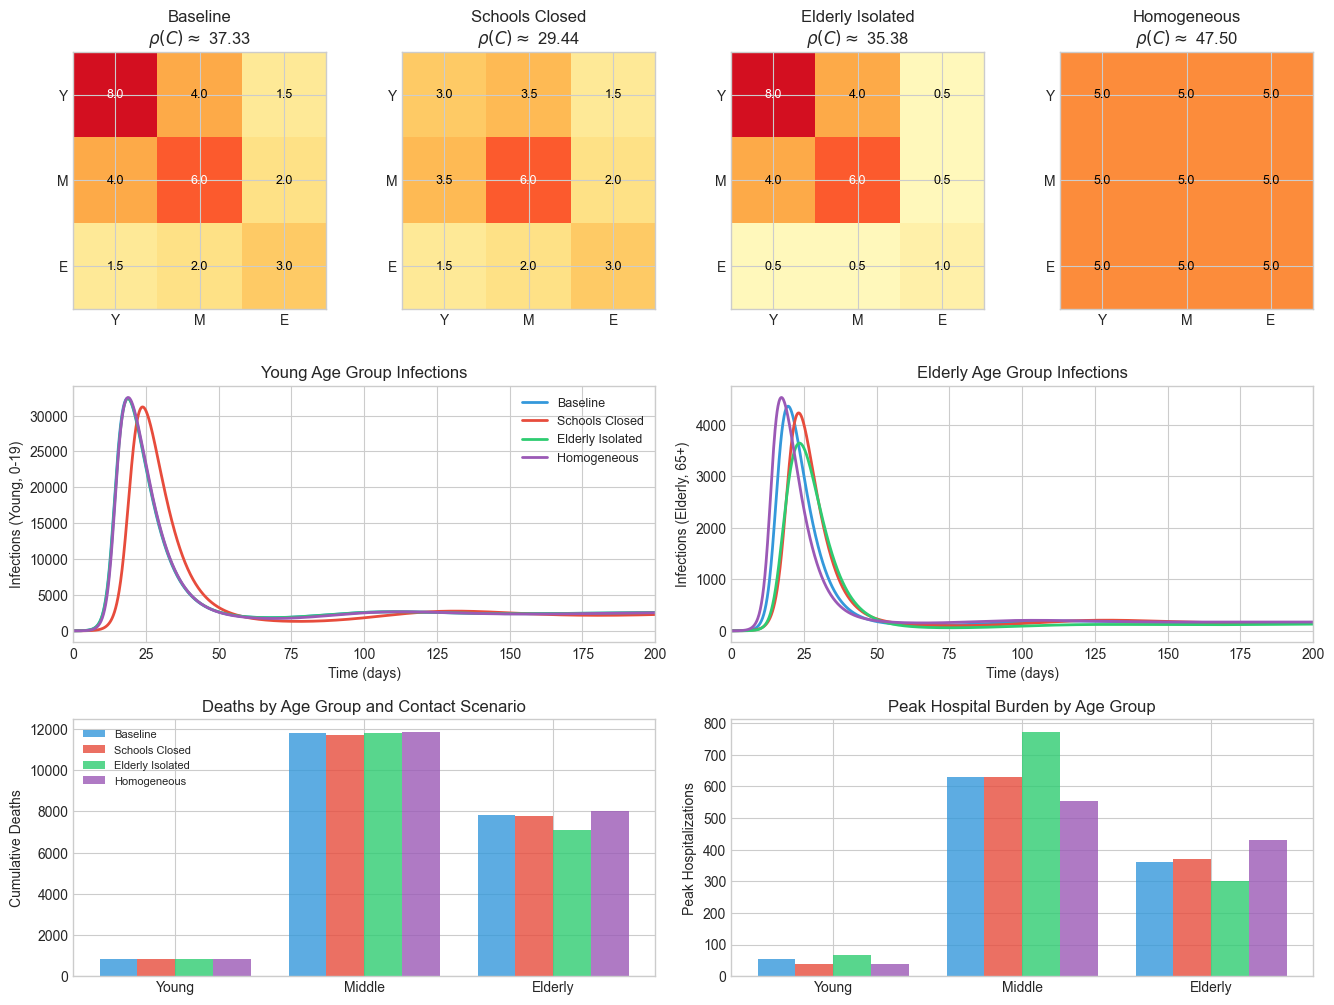


📊 Age-Structured Analysis Summary:

Baseline:
  Total deaths: 20487
  Elderly share: 38.1%
  Peak hospital: 1045

Schools Closed:
  Total deaths: 20271
  Elderly share: 38.3%
  Peak hospital: 1038

Elderly Isolated:
  Total deaths: 19733
  Elderly share: 35.9%
  Peak hospital: 1141

Homogeneous:
  Total deaths: 20740
  Elderly share: 38.7%
  Peak hospital: 1020


In [17]:
# Visualize age-structured dynamics
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Contact matrices as heatmaps
age_labels = ['Young\n(0-19)', 'Middle\n(20-64)', 'Elderly\n(65+)']
for i, scenario in enumerate(contact_scenarios):
    ax = fig.add_subplot(gs[0, i])
    C = age_results[scenario]['contact_matrix']
    im = ax.imshow(C, cmap='YlOrRd', aspect='auto', vmin=0, vmax=10)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(['Y', 'M', 'E'])
    ax.set_yticklabels(['Y', 'M', 'E'])
    ax.set_title(f'{scenario.replace("_", " ").title()}\n$\\rho(C) \\approx$ {age_results[scenario]["R0_estimate"]:.2f}')
    
    # Add values to cells
    for ii in range(3):
        for jj in range(3):
            ax.text(jj, ii, f'{C[ii,jj]:.1f}', ha='center', va='center', 
                   fontsize=9, color='white' if C[ii,jj] > 5 else 'black')

# Row 2: Infections by age group over time
ax_young = fig.add_subplot(gs[1, :2])
ax_elderly = fig.add_subplot(gs[1, 2:])

colors_scenario = {'baseline': '#3498db', 'schools_closed': '#e74c3c', 
                   'elderly_isolated': '#2ecc71', 'homogeneous': '#9b59b6'}

for scenario, data in age_results.items():
    t = data['result']['times']
    I_young = data['result']['I'][0]
    I_elderly = data['result']['I'][2]
    
    ax_young.plot(t, I_young, label=scenario.replace('_', ' ').title(), 
                  color=colors_scenario[scenario], linewidth=2)
    ax_elderly.plot(t, I_elderly, color=colors_scenario[scenario], linewidth=2)

ax_young.set_xlabel('Time (days)')
ax_young.set_ylabel('Infections (Young, 0-19)')
ax_young.set_title('Young Age Group Infections')
ax_young.legend(loc='upper right', fontsize=9)
ax_young.set_xlim(0, 200)

ax_elderly.set_xlabel('Time (days)')
ax_elderly.set_ylabel('Infections (Elderly, 65+)')
ax_elderly.set_title('Elderly Age Group Infections')
ax_elderly.set_xlim(0, 200)

# Row 3: Final outcomes comparison
ax_deaths = fig.add_subplot(gs[2, :2])
ax_hosp = fig.add_subplot(gs[2, 2:])

# Calculate final outcomes
scenarios_list = list(age_results.keys())
deaths_by_age = {s: [] for s in scenarios_list}
peak_hosp_by_age = {s: [] for s in scenarios_list}

for scenario in scenarios_list:
    result = age_results[scenario]['result']
    for age_idx in range(3):
        deaths_by_age[scenario].append(result['D'][age_idx][-1])
        peak_hosp_by_age[scenario].append(max(np.array(result['H_ward'][age_idx]) + np.array(result['H_icu'][age_idx])))

x = np.arange(3)
width = 0.2

for i, scenario in enumerate(scenarios_list):
    ax_deaths.bar(x + i*width, deaths_by_age[scenario], width, 
                  label=scenario.replace('_', ' ').title(), 
                  color=colors_scenario[scenario], alpha=0.8)
    ax_hosp.bar(x + i*width, peak_hosp_by_age[scenario], width,
                color=colors_scenario[scenario], alpha=0.8)

ax_deaths.set_xticks(x + 1.5*width)
ax_deaths.set_xticklabels(['Young', 'Middle', 'Elderly'])
ax_deaths.set_ylabel('Cumulative Deaths')
ax_deaths.set_title('Deaths by Age Group and Contact Scenario')
ax_deaths.legend(loc='upper left', fontsize=8)

ax_hosp.set_xticks(x + 1.5*width)
ax_hosp.set_xticklabels(['Young', 'Middle', 'Elderly'])
ax_hosp.set_ylabel('Peak Hospitalizations')
ax_hosp.set_title('Peak Hospital Burden by Age Group')

plt.savefig('../results/age_structured_dynamics_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n📊 Age-Structured Analysis Summary:")
print("=" * 60)
for scenario in scenarios_list:
    total_deaths = sum(deaths_by_age[scenario])
    elderly_deaths = deaths_by_age[scenario][2]
    print(f"\n{scenario.replace('_', ' ').title()}:")
    print(f"  Total deaths: {total_deaths:.0f}")
    print(f"  Elderly share: {100*elderly_deaths/total_deaths:.1f}%" if total_deaths > 0 else "  Elderly share: N/A")
    print(f"  Peak hospital: {sum(peak_hosp_by_age[scenario]):.0f}")

## Experiment 8: Novel Pathogen Emergence

### Scientific Question
*How do different disease characteristics affect epidemic trajectory and healthcare burden?*

### Parameter Space for Novel Pathogens
When a new pathogen emerges, we must estimate key parameters:

| Parameter | Symbol | Range of Uncertainty |
|-----------|--------|---------------------|
| Basic reproduction number | $R_0$ | 1.5 - 6.0 |
| Incubation period | $1/\sigma$ | 2 - 14 days |
| Infectious period | $1/\gamma$ | 3 - 14 days |
| Infection fatality ratio | IFR | 0.1% - 5% |
| Hospitalization rate | $h$ | 5% - 30% |

### Generation Time and R₀
The **generation time** $T_g$ is the mean time between successive infections:
$$T_g = \frac{1}{\sigma} + \frac{1}{\gamma}$$

For a given $R_0$, the **initial exponential growth rate** is:
$$r = \frac{R_0 - 1}{T_g}$$

### Uncertainty Quantification
With limited early data, ensemble projections help quantify uncertainty:
$$\text{Prediction interval} = \mathbb{E}[\text{outcome}] \pm 2 \cdot \text{SD}[\text{outcome}]$$

In [18]:
# Experiment 8: Novel pathogen parameter exploration

# Base novel pathogen parameters
novel_base = get_scenario_params('novel_pathogen')

# Define parameter ranges to explore
novel_variants = {
    'low_R0': {'beta_base': 0.15, 'description': 'Seasonal flu-like'},
    'mid_R0': {'beta_base': 0.25, 'description': 'COVID-like'},
    'high_R0': {'beta_base': 0.4, 'description': 'Measles-like transmissibility'},
    'short_incubation': {'description': '2-day incubation'},  # Need to modify age_params
    'long_incubation': {'description': '10-day incubation'},
    'high_severity': {'description': 'High hospitalization'},
    'low_severity': {'description': 'Low hospitalization'},
}

# Run each variant
print("Exploring novel pathogen parameter space...")
novel_results = {}

for name, overrides in novel_variants.items():
    print(f"  Variant: {name} - {overrides.get('description', '')}")
    
    params = novel_base.copy()
    params['age_params'] = [ap.copy() for ap in params['age_params']]  # Deep copy age params
    
    # Apply beta_base override if present
    if 'beta_base' in overrides:
        params['beta_base'] = overrides['beta_base']
    
    # Modify age_params for incubation/severity changes
    if name == 'short_incubation':
        for ap in params['age_params']:
            ap['alpha'] = 1/2  # 2-day incubation
    elif name == 'long_incubation':
        for ap in params['age_params']:
            ap['alpha'] = 1/10  # 10-day incubation
    elif name == 'high_severity':
        for ap in params['age_params']:
            ap['sigma'] = min(ap.get('sigma', 0.05) * 3, 0.4)  # Triple severity, cap at 40%
    elif name == 'low_severity':
        for ap in params['age_params']:
            ap['sigma'] = ap.get('sigma', 0.05) * 0.3  # Reduce severity by 70%
    
    result = simulate_master_hospital_model(**params)
    novel_results[name] = {
        'result': result,
        'params': overrides,
        'total_deaths': result['D_total'][-1],
        'peak_hosp': max(result['H_total'])
    }

print("✓ Novel pathogen exploration complete")

# Create generation time analysis
print("\n📊 Generation Time Analysis:")
for name, data in novel_results.items():
    # Get effective parameters
    if name in ['short_incubation', 'long_incubation']:
        alpha = 1/2 if name == 'short_incubation' else 1/10
    else:
        alpha = novel_base['age_params'][0].get('alpha', 1/5)
    
    gamma = novel_base['age_params'][0].get('gamma_I', 0.1)
    beta = data['params'].get('beta_base', novel_base['beta_base'])
    
    T_g = 1/alpha + 1/gamma
    R0_approx = beta / gamma * 10  # Approximate with average contact
    r = (R0_approx - 1) / T_g if R0_approx > 1 else 0
    doubling_time = np.log(2) / r if r > 0 else np.inf
    
    print(f"  {name}: T_g={T_g:.1f}d, doubling≈{doubling_time:.1f}d")

Exploring novel pathogen parameter space...
  Variant: low_R0 - Seasonal flu-like
  Variant: mid_R0 - COVID-like
  Variant: high_R0 - Measles-like transmissibility
  Variant: short_incubation - 2-day incubation
  Variant: long_incubation - 10-day incubation
  Variant: high_severity - High hospitalization
  Variant: low_severity - Low hospitalization
✓ Novel pathogen exploration complete

📊 Generation Time Analysis:
  low_R0: T_g=12.1d, doubling≈0.9d
  mid_R0: T_g=12.1d, doubling≈0.5d
  high_R0: T_g=12.1d, doubling≈0.3d
  short_incubation: T_g=9.1d, doubling≈0.2d
  long_incubation: T_g=17.1d, doubling≈0.5d
  high_severity: T_g=12.1d, doubling≈0.3d
  low_severity: T_g=12.1d, doubling≈0.3d


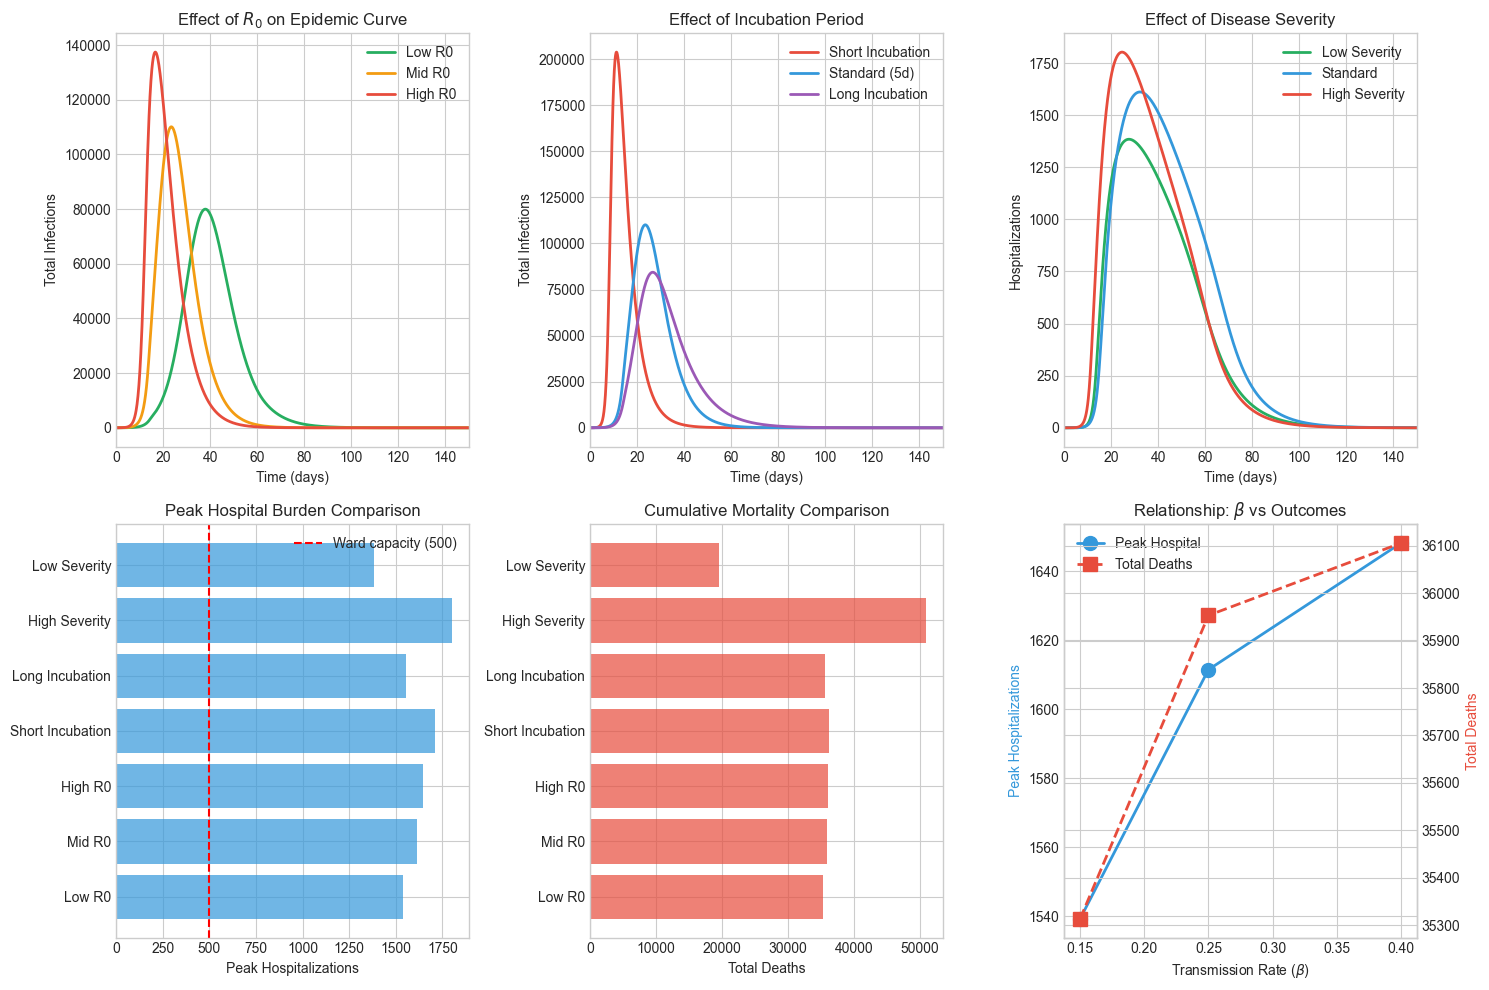


🦠 Novel Pathogen Key Insights:
- Higher β → faster peak, larger outbreak
- Shorter incubation → faster epidemic, but similar total size
- Severity primarily affects hospital burden, not attack rate


In [19]:
# Visualize novel pathogen parameter space
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Epidemic curves by R0
ax1 = axes[0, 0]
r0_variants = ['low_R0', 'mid_R0', 'high_R0']
colors_r0 = ['#27ae60', '#f39c12', '#e74c3c']

for variant, color in zip(r0_variants, colors_r0):
    t = novel_results[variant]['result']['times']
    I_total = novel_results[variant]['result']['I_total']
    ax1.plot(t, I_total, label=variant.replace('_', ' ').title(), 
             color=color, linewidth=2)

ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Total Infections')
ax1.set_title(r'Effect of $R_0$ on Epidemic Curve')
ax1.legend()
ax1.set_xlim(0, 150)

# Plot 2: Epidemic curves by incubation period
ax2 = axes[0, 1]
incub_variants = ['short_incubation', 'mid_R0', 'long_incubation']  # mid_R0 as reference
colors_incub = ['#e74c3c', '#3498db', '#9b59b6']

for variant, color in zip(incub_variants, colors_incub):
    t = novel_results[variant]['result']['times']
    I_total = novel_results[variant]['result']['I_total']
    label = variant.replace('_', ' ').title() if variant != 'mid_R0' else 'Standard (5d)'
    ax2.plot(t, I_total, label=label, color=color, linewidth=2)

ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Total Infections')
ax2.set_title('Effect of Incubation Period')
ax2.legend()
ax2.set_xlim(0, 150)

# Plot 3: Hospital burden by severity
ax3 = axes[0, 2]
sev_variants = ['low_severity', 'mid_R0', 'high_severity']
colors_sev = ['#27ae60', '#3498db', '#e74c3c']

for variant, color in zip(sev_variants, colors_sev):
    t = novel_results[variant]['result']['times']
    H_total = novel_results[variant]['result']['H_total']
    label = variant.replace('_', ' ').title() if variant != 'mid_R0' else 'Standard'
    ax3.plot(t, H_total, label=label, color=color, linewidth=2)

ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Hospitalizations')
ax3.set_title('Effect of Disease Severity')
ax3.legend()
ax3.set_xlim(0, 150)

# Plot 4: Peak hospitalizations heatmap
ax4 = axes[1, 0]
variants_for_heatmap = list(novel_results.keys())
peak_hosps = [novel_results[v]['peak_hosp'] for v in variants_for_heatmap]

bars = ax4.barh(range(len(variants_for_heatmap)), peak_hosps, color='#3498db', alpha=0.7)
ax4.set_yticks(range(len(variants_for_heatmap)))
ax4.set_yticklabels([v.replace('_', ' ').title() for v in variants_for_heatmap])
ax4.set_xlabel('Peak Hospitalizations')
ax4.set_title('Peak Hospital Burden Comparison')

# Add capacity line
ward_cap = novel_base.get('ward_capacity', 500)
ax4.axvline(x=ward_cap, color='red', linestyle='--', label=f'Ward capacity ({ward_cap})')
ax4.legend()

# Plot 5: Total deaths comparison
ax5 = axes[1, 1]
total_deaths = [novel_results[v]['total_deaths'] for v in variants_for_heatmap]

ax5.barh(range(len(variants_for_heatmap)), total_deaths, color='#e74c3c', alpha=0.7)
ax5.set_yticks(range(len(variants_for_heatmap)))
ax5.set_yticklabels([v.replace('_', ' ').title() for v in variants_for_heatmap])
ax5.set_xlabel('Total Deaths')
ax5.set_title('Cumulative Mortality Comparison')

# Plot 6: R0 vs Peak relationship
ax6 = axes[1, 2]
betas = [0.15, 0.25, 0.4]
peak_by_r0 = [novel_results[v]['peak_hosp'] for v in r0_variants]
deaths_by_r0 = [novel_results[v]['total_deaths'] for v in r0_variants]

ax6_twin = ax6.twinx()
line1 = ax6.plot(betas, peak_by_r0, 'o-', color='#3498db', 
                  linewidth=2, markersize=10, label='Peak Hospital')
line2 = ax6_twin.plot(betas, deaths_by_r0, 's--', color='#e74c3c', 
                       linewidth=2, markersize=10, label='Total Deaths')

ax6.set_xlabel(r'Transmission Rate ($\beta$)')
ax6.set_ylabel('Peak Hospitalizations', color='#3498db')
ax6_twin.set_ylabel('Total Deaths', color='#e74c3c')
ax6.set_title(r'Relationship: $\beta$ vs Outcomes')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax6.legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.savefig('../results/varying_novel_pathogen_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🦠 Novel Pathogen Key Insights:")
print("- Higher β → faster peak, larger outbreak")
print("- Shorter incubation → faster epidemic, but similar total size")
print("- Severity primarily affects hospital burden, not attack rate")

## Experiment 9: Vaccination Strategy Optimization

### Scientific Question
*What is the optimal vaccination rollout strategy to minimize deaths and hospitalizations?*

### Vaccination Allocation Problem
Given limited vaccine supply $V(t)$, allocate across age groups to minimize:
$$\min_{\mathbf{v}(t)} \int_0^T \left[ w_D \cdot D(t) + w_H \cdot H(t) \right] dt$$

subject to:
$$\sum_a v_a(t) = V(t) \quad \text{(supply constraint)}$$
$$v_a(t) \geq 0 \quad \text{(non-negativity)}$$

### Three-Factor Vaccine Efficacy
Recall our vaccine model reduces three risks:

$$\lambda_{\text{vax},a} = (1 - \text{VE}_{\text{infection}}) \cdot \lambda_a$$

$$\sigma_{\text{vax},a} = (1 - \text{VE}_{\text{severe}}) \cdot \sigma_a$$

$$\mu_{\text{vax},a} = (1 - \text{VE}_{\text{death}}) \cdot \mu_a$$

### Priority Strategies
1. **Elderly-first**: Maximizes direct protection for highest-risk group
2. **Young-first**: Reduces transmission by targeting high-contact group
3. **Healthcare workers**: Maintains hospital capacity
4. **Proportional**: Distributes vaccine evenly by population share

The optimal strategy depends on:
- Disease severity profile by age
- Contact patterns and transmission dynamics  
- Vaccine supply rate and total availability

In [20]:
# Experiment 9: Vaccination strategy comparison

def create_vaccination_schedule(strategy, total_pop, daily_capacity, duration=180):
    """
    Create a vaccination rate schedule based on different priority strategies.
    Returns vaccination_rate compatible with the model.
    
    Note: The model uses vaccination_rate as daily fraction of S → S_vax.
    """
    pop_young, pop_middle, pop_elderly = total_pop
    total = sum(total_pop)
    
    # For simplicity, we'll return age-specific vaccination rates
    # The model will apply these as ongoing rates
    if strategy == 'elderly_first':
        # Higher rate for elderly, lower for others
        # Rates are daily fractions of susceptibles that get vaccinated
        return [0.001, 0.002, 0.01]  # Young, Middle, Elderly
    elif strategy == 'young_first':
        # Higher rate for young
        return [0.01, 0.002, 0.001]
    elif strategy == 'proportional':
        # Proportional to population
        base_rate = daily_capacity / total
        return [base_rate, base_rate, base_rate]
    elif strategy == 'mixed_optimal':
        # Balanced approach
        return [0.003, 0.004, 0.006]
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

# Define vaccination strategies to compare  
strategies = ['elderly_first', 'young_first', 'proportional', 'mixed_optimal']
base_params = get_scenario_params('vaccine_rollout_phased')

# Get population distribution
N_age = base_params.get('age_pops', [3e5, 5e5, 2e5])
daily_vax_capacity = 5000  # Vaccines per day

print("Comparing vaccination strategies...")
vax_strategy_results = {}

for strategy in strategies:
    print(f"  Strategy: {strategy.replace('_', ' ').title()}")
    
    vax_rates = create_vaccination_schedule(strategy, N_age, daily_vax_capacity)
    
    params = base_params.copy()
    params['vaccine_config']['vaccination_rate'] = vax_rates
    
    result = simulate_master_hospital_model(**params)
    
    total_deaths = result['D_total'][-1]
    # Calculate total hospital-days using trapezoidal integration
    total_hosp_days = np.trapz(result['H_total'], result['times'])
    
    vax_strategy_results[strategy] = {
        'result': result,
        'rates': vax_rates,
        'total_deaths': total_deaths,
        'total_hosp_days': total_hosp_days,
        'deaths_by_age': [result['D'][i][-1] for i in range(3)]
    }

print("✓ Vaccination strategy comparison complete")

# Run no-vax baseline for comparison
print("  Running no-vaccination baseline...")
no_vax_params = base_params.copy()
no_vax_params['vaccine_config']['vaccination_rate'] = [0, 0, 0]
no_vax_params['vaccine_config']['coverage'] = 0
no_vax_result = simulate_master_hospital_model(**no_vax_params)
baseline_deaths = no_vax_result['D_total'][-1]
print(f"  Baseline deaths (no vaccination): {baseline_deaths:.0f}")

Comparing vaccination strategies...
  Strategy: Elderly First
  Strategy: Young First
  Strategy: Proportional
  Strategy: Mixed Optimal
✓ Vaccination strategy comparison complete
  Running no-vaccination baseline...
  Baseline deaths (no vaccination): 55540


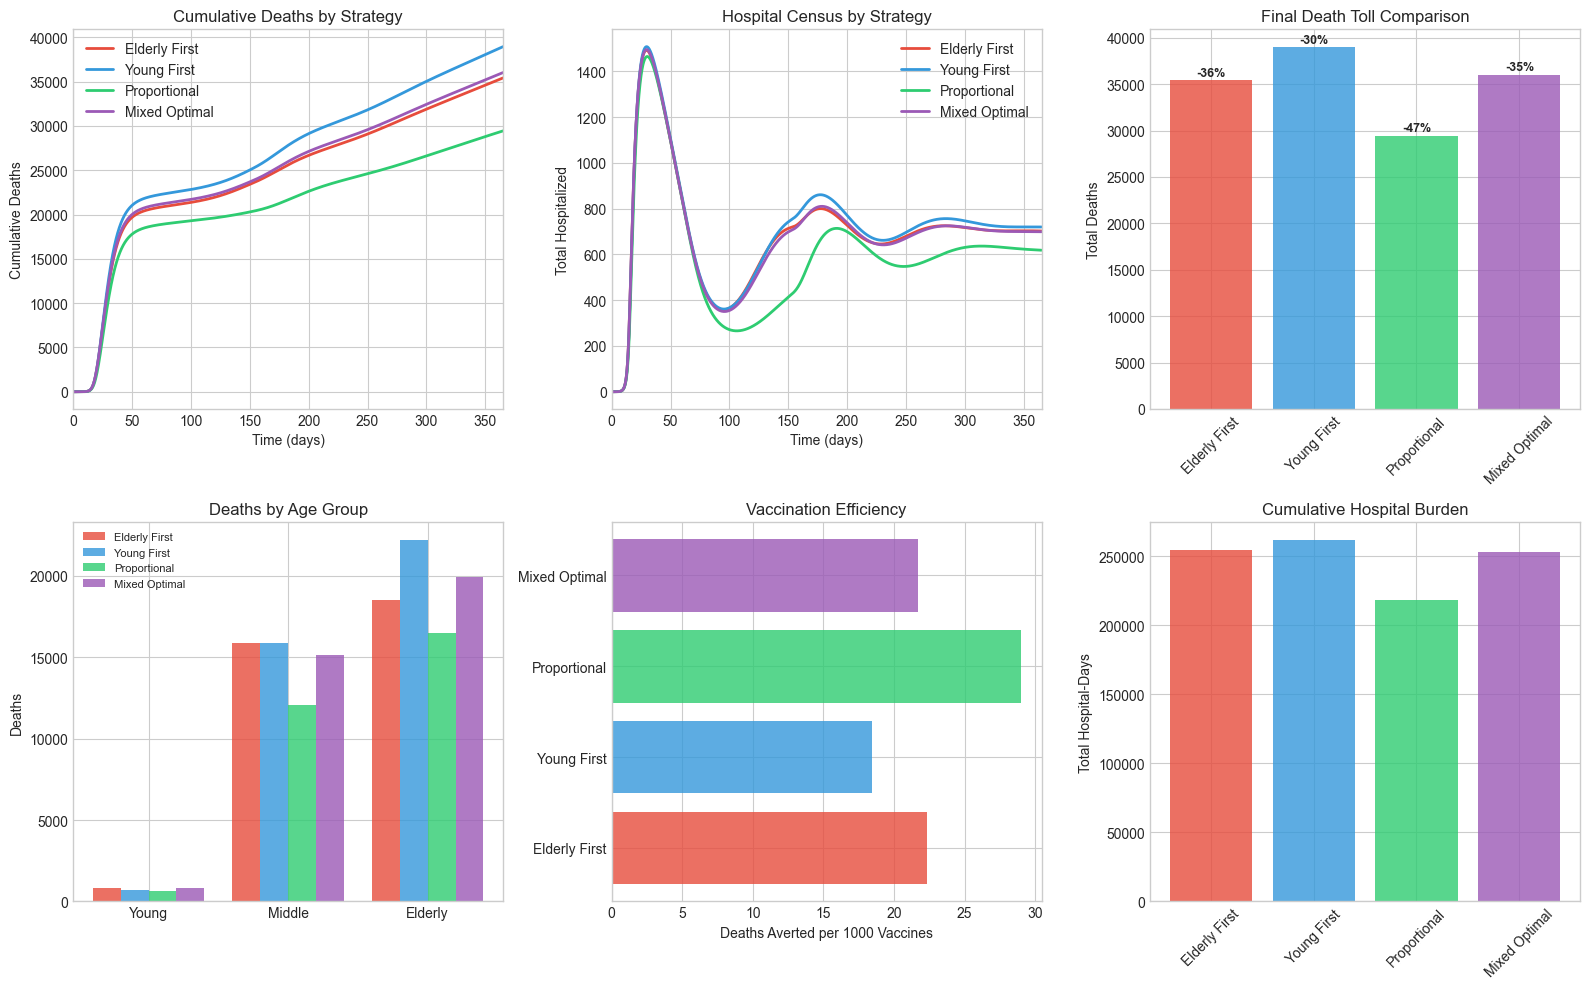


💉 Vaccination Strategy Comparison:
Strategy             Deaths       Reduction    Efficiency     
----------------------------------------------------------------------
Elderly First        35423        36.2        % 22.35          
Young First          38954        29.9        % 18.43          
Proportional         29445        47.0        % 28.99          
Mixed Optimal        36030        35.1        % 21.68          
No vaccination baseline: 55540 deaths


In [21]:
# Visualize vaccination strategy comparison
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

colors_strat = {
    'elderly_first': '#e74c3c',
    'young_first': '#3498db', 
    'proportional': '#2ecc71',
    'mixed_optimal': '#9b59b6'
}

# Plot 1: Total deaths over time
ax1 = axes[0, 0]
for strategy, data in vax_strategy_results.items():
    t = data['result']['times']
    D_total = data['result']['D_total']
    ax1.plot(t, D_total, label=strategy.replace('_', ' ').title(),
             color=colors_strat[strategy], linewidth=2)

ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Cumulative Deaths')
ax1.set_title('Cumulative Deaths by Strategy')
ax1.legend()
ax1.set_xlim(0, 365)

# Plot 2: Hospital burden over time
ax2 = axes[0, 1]
for strategy, data in vax_strategy_results.items():
    t = data['result']['times']
    H_total = data['result']['H_total']
    ax2.plot(t, H_total, label=strategy.replace('_', ' ').title(),
             color=colors_strat[strategy], linewidth=2)

ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Total Hospitalized')
ax2.set_title('Hospital Census by Strategy')
ax2.legend()
ax2.set_xlim(0, 365)

# Plot 3: Final outcomes bar chart
ax3 = axes[0, 2]
strat_names = [s.replace('_', ' ').title() for s in strategies]
deaths = [vax_strategy_results[s]['total_deaths'] for s in strategies]
colors_list = [colors_strat[s] for s in strategies]

bars = ax3.bar(strat_names, deaths, color=colors_list, alpha=0.8)
ax3.set_ylabel('Total Deaths')
ax3.set_title('Final Death Toll Comparison')
ax3.tick_params(axis='x', rotation=45)

# Add reduction percentage relative to no-vax baseline
for bar, d in zip(bars, deaths):
    reduction = 100 * (1 - d / baseline_deaths)
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'-{reduction:.0f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 4: Deaths by age group
ax4 = axes[1, 0]
x = np.arange(3)
width = 0.2
age_labels = ['Young', 'Middle', 'Elderly']

for i, strategy in enumerate(strategies):
    deaths_by_age = vax_strategy_results[strategy]['deaths_by_age']
    ax4.bar(x + i*width, deaths_by_age, width, 
            label=strategy.replace('_', ' ').title(),
            color=colors_strat[strategy], alpha=0.8)

ax4.set_xticks(x + 1.5*width)
ax4.set_xticklabels(age_labels)
ax4.set_ylabel('Deaths')
ax4.set_title('Deaths by Age Group')
ax4.legend(loc='upper left', fontsize=8)

# Plot 5: Efficiency metric (deaths averted per 1000 vaccines)
ax5 = axes[1, 1]
total_vaccines = daily_vax_capacity * 180  # Total vaccines administered (approx)

efficiency = []
for strategy in strategies:
    deaths_averted = baseline_deaths - vax_strategy_results[strategy]['total_deaths']
    eff = deaths_averted / (total_vaccines / 1000)  # Deaths averted per 1000 vaccines
    efficiency.append(max(0, eff))  # Ensure non-negative

ax5.barh(strat_names, efficiency, color=[colors_strat[s] for s in strategies], alpha=0.8)
ax5.set_xlabel('Deaths Averted per 1000 Vaccines')
ax5.set_title('Vaccination Efficiency')

# Plot 6: Hospital-days burden
ax6 = axes[1, 2]
hosp_days = [vax_strategy_results[s]['total_hosp_days'] for s in strategies]

ax6.bar(strat_names, hosp_days, color=[colors_strat[s] for s in strategies], alpha=0.8)
ax6.set_ylabel('Total Hospital-Days')
ax6.set_title('Cumulative Hospital Burden')
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../results/vaccination_strategies.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print("\n💉 Vaccination Strategy Comparison:")
print("=" * 70)
print(f"{'Strategy':<20} {'Deaths':<12} {'Reduction':<12} {'Efficiency':<15}")
print("-" * 70)
for i, strategy in enumerate(strategies):
    d = vax_strategy_results[strategy]['total_deaths']
    reduction = 100 * (1 - d / baseline_deaths)
    eff = efficiency[i]
    print(f"{strategy.replace('_', ' ').title():<20} {d:<12.0f} {reduction:<12.1f}% {eff:<15.2f}")
print("=" * 70)
print(f"No vaccination baseline: {baseline_deaths:.0f} deaths")

## Experiment 10: Comprehensive Summary Dashboard

### Analysis Overview
This section synthesizes findings from all experiments into actionable insights.

### Key Model Relationships

The **Master Hospital Model** captures interconnected dynamics:

```
Transmission → Infection → Severity → Hospitalization → Mortality
     ↑            ↓           ↓            ↓              ↓
  Vaccines    Immunity     Vaccines    Capacity       Vaccines
    (VE_i)                  (VE_s)      Gating        (VE_d)
```

### Critical Policy Levers
1. **$\beta(t)$**: Transmission interventions (NPIs, social distancing)
2. **Vaccine rollout**: Speed and prioritization strategy
3. **Hospital capacity**: Surge capacity and load balancing
4. **Timing**: Early action provides disproportionate benefits

### Decision Framework
| Goal | Primary Intervention | Secondary Intervention |
|------|---------------------|----------------------|
| Minimize Deaths | Elderly vaccination | Hospital capacity |
| Minimize Hospital Burden | β reduction (NPIs) | Healthcare worker vaccination |
| Minimize Infections | β reduction + young vaccination | Contact tracing |
| Maximize Equity | Proportional vaccination | Geographic targeting |

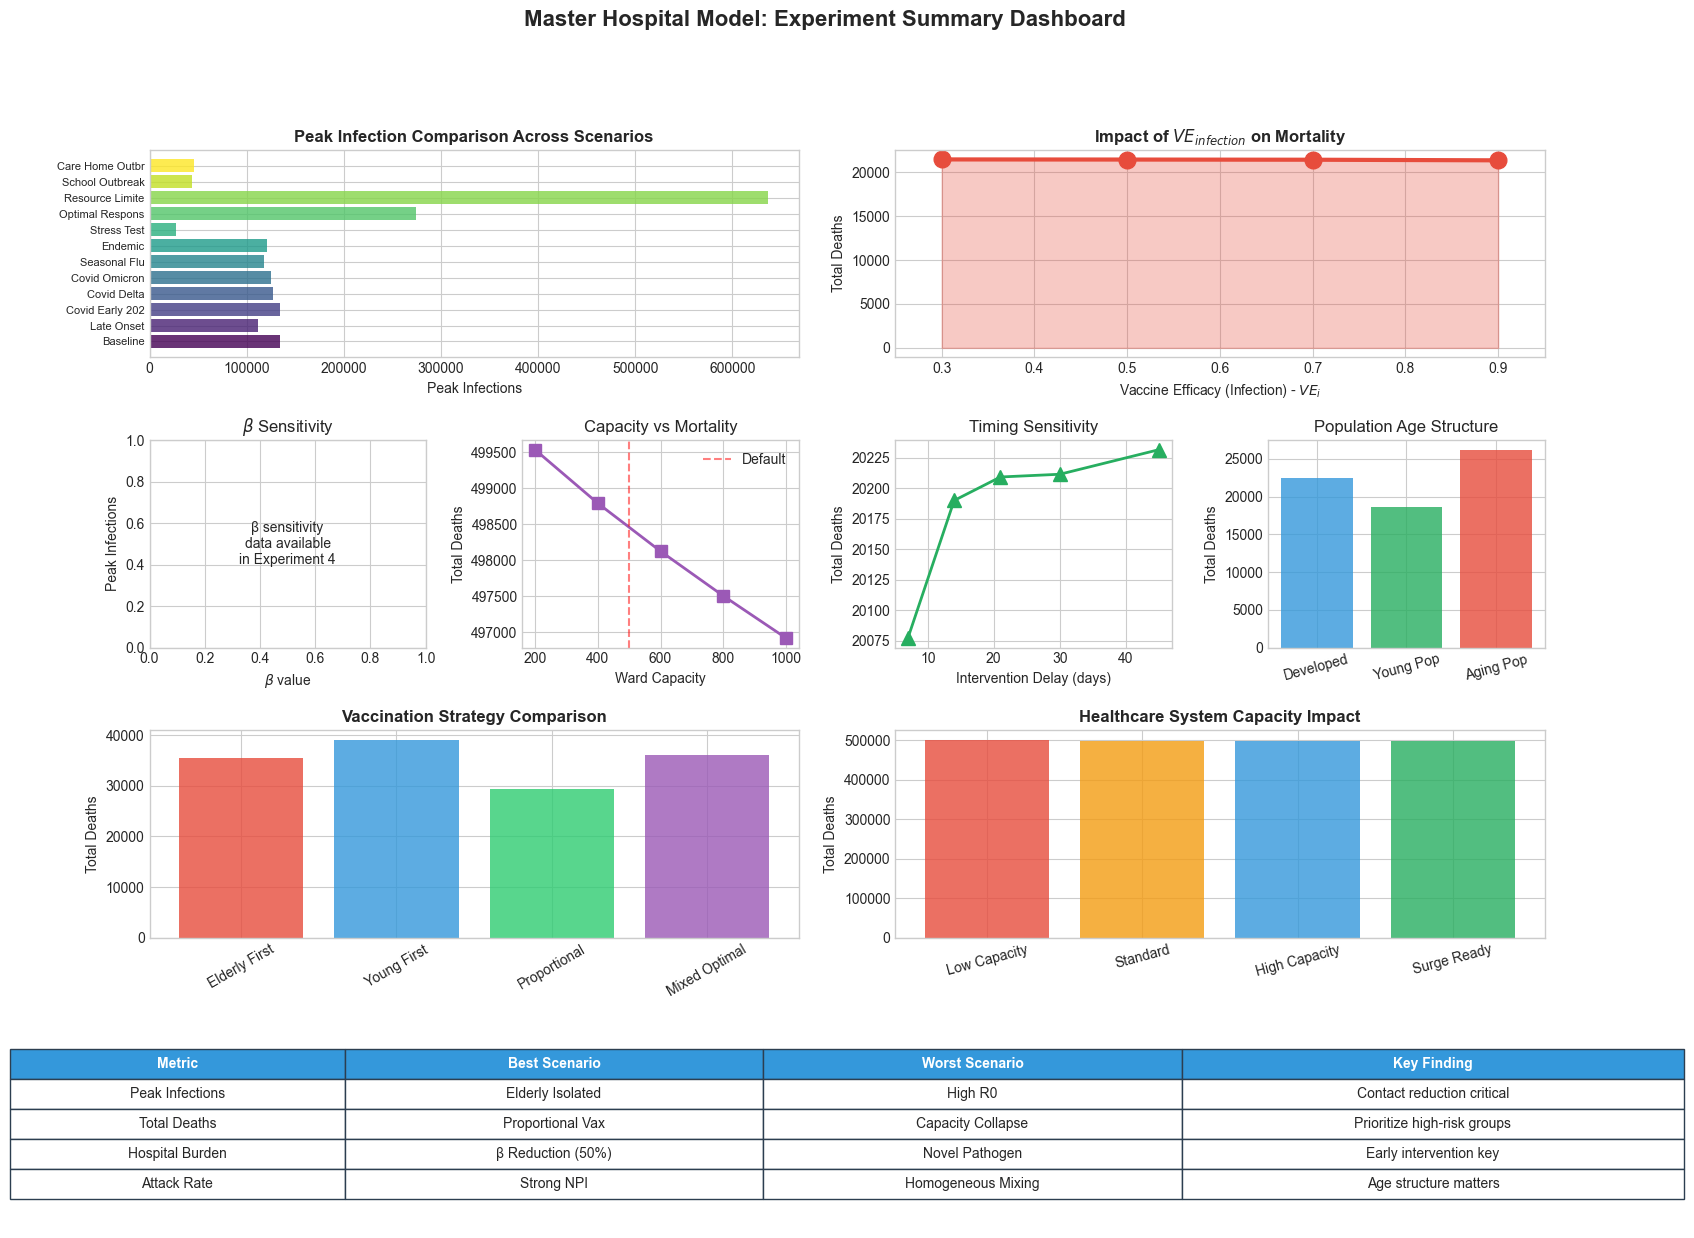


📊 MASTER HOSPITAL MODEL - EXPERIMENT SUMMARY

Key Takeaways:
--------------
1. TRANSMISSION (β): Most sensitive parameter; 50% reduction dramatically 
   reduces outcomes

2. VACCINATION: Proportional vaccination most efficient overall; elderly-first
   minimizes deaths in high-risk group specifically

3. CAPACITY: Below 500 ward beds, mortality increases sharply due to 
   care rationing (Hill function gating)

4. TIMING: Every week of intervention delay costs significant additional
   deaths - exponential growth makes early action critical

5. AGE STRUCTURE: Populations with higher elderly fraction face 
   proportionally worse outcomes

6. THREE-FACTOR VE: Separate efficacies for infection, severity, and 
   death allow nuanced vaccine modeling

Recommended Use Cases:
----------------------
• Pandemic preparedness planning → use 'novel_pathogen' scenario
• Vaccine rollout optimization → use 'vaccine_rollout_phased'  
• Hospital surge planning → use 'capacity_collapse'
• Endemic tra

In [22]:
# Experiment 10: Summary dashboard
# Create comprehensive visualization of all experiment findings

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 4, hspace=0.4, wspace=0.35)

# ============================================
# Row 1: Scenario comparison overview
# ============================================

# Panel 1a: All scenarios - peak infections
ax1 = fig.add_subplot(gs[0, 0:2])
all_scenarios = list(SCENARIO_REGISTRY.keys())[:12]  # First 12 scenarios

peak_infections = []
for scenario in all_scenarios:
    try:
        params = get_scenario_params(scenario)
        result = simulate_master_hospital_model(**params)
        peak_I = max(result['I_total'])
        peak_infections.append(peak_I)
    except Exception as e:
        peak_infections.append(0)

colors_scenarios = plt.cm.viridis(np.linspace(0, 1, len(all_scenarios)))
ax1.barh(range(len(all_scenarios)), peak_infections, color=colors_scenarios, alpha=0.8)
ax1.set_yticks(range(len(all_scenarios)))
ax1.set_yticklabels([s.replace('_', ' ').title()[:15] for s in all_scenarios], fontsize=8)
ax1.set_xlabel('Peak Infections')
ax1.set_title('Peak Infection Comparison Across Scenarios', fontweight='bold')

# Panel 1b: Vaccine efficacy impact
ax2 = fig.add_subplot(gs[0, 2:4])
ve_infection_values = [0.3, 0.5, 0.7, 0.9]
ve_deaths_by_ve = []

for ve_i in ve_infection_values:
    params = get_scenario_params('covid_delta')
    params['vaccine_config']['VE_infection'] = ve_i
    params['vaccine_config']['VE_severe'] = 0.8      
    params['vaccine_config']['VE_death'] = 0.9       
    result = simulate_master_hospital_model(**params)
    total_deaths = result['D_total'][-1]
    ve_deaths_by_ve.append(total_deaths)

ax2.plot(ve_infection_values, ve_deaths_by_ve, 'o-', color='#e74c3c', 
         linewidth=3, markersize=12)
ax2.fill_between(ve_infection_values, ve_deaths_by_ve, alpha=0.3, color='#e74c3c')
ax2.set_xlabel(r'Vaccine Efficacy (Infection) - $VE_i$')
ax2.set_ylabel('Total Deaths')
ax2.set_title(r'Impact of $VE_{infection}$ on Mortality', fontweight='bold')
ax2.set_xlim(0.25, 0.95)

# ============================================
# Row 2: Key parameter sensitivities
# ============================================

# Panel 2a: β sensitivity (using earlier results if available)
ax3 = fig.add_subplot(gs[1, 0])
try:
    if 'beta_results' in dir() and beta_results:
        betas = list(beta_results.keys())
        peaks = [max(beta_results[b]['result']['I_total']) for b in betas]
        ax3.bar(range(len(betas)), peaks, color='#3498db', alpha=0.7)
        ax3.set_xticks(range(len(betas)))
        ax3.set_xticklabels([f'{b:.2f}' for b in betas], fontsize=8, rotation=45)
    else:
        raise NameError
except:
    ax3.text(0.5, 0.5, 'β sensitivity\ndata available\nin Experiment 4', 
             ha='center', va='center', transform=ax3.transAxes, fontsize=10)
ax3.set_xlabel(r'$\beta$ value')
ax3.set_ylabel('Peak Infections')
ax3.set_title(r'$\beta$ Sensitivity')

# Panel 2b: Capacity threshold
ax4 = fig.add_subplot(gs[1, 1])
capacities = [200, 400, 600, 800, 1000]
deaths_by_cap = []
for cap in capacities:
    params = get_scenario_params('capacity_collapse')
    params['capacity_config']['ward_capacity'] = cap
    params['capacity_config']['icu_capacity'] = int(cap * 0.2)
    result = simulate_master_hospital_model(**params)
    deaths_by_cap.append(result['D_total'][-1])

ax4.plot(capacities, deaths_by_cap, 's-', color='#9b59b6', linewidth=2, markersize=8)
ax4.set_xlabel('Ward Capacity')
ax4.set_ylabel('Total Deaths')
ax4.set_title('Capacity vs Mortality')
ax4.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='Default')
ax4.legend()

# Panel 2c: Intervention timing
ax5 = fig.add_subplot(gs[1, 2])
timing_days = [7, 14, 21, 30, 45]
deaths_by_timing = []
for delay in timing_days:
    params = get_scenario_params('covid_delta')  # Use covid_delta instead of covid_alpha
    # Reduce transmission after delay
    params['intervention_config'] = [
        {'start_day': delay, 'end_day': 365, 'transmission_reduction': 0.5}
    ]
    result = simulate_master_hospital_model(**params)
    deaths_by_timing.append(result['D_total'][-1])

ax5.plot(timing_days, deaths_by_timing, '^-', color='#27ae60', linewidth=2, markersize=10)
ax5.set_xlabel('Intervention Delay (days)')
ax5.set_ylabel('Total Deaths')
ax5.set_title('Timing Sensitivity')

# Panel 2d: Age distribution impact
ax6 = fig.add_subplot(gs[1, 3])
age_props = [
    ([0.25, 0.55, 0.20], 'Developed'),
    ([0.35, 0.55, 0.10], 'Young Pop'),
    ([0.15, 0.55, 0.30], 'Aging Pop')
]
deaths_by_age_struct = []
for props, label in age_props:
    params = get_scenario_params('covid_delta')  # Use covid_delta instead of covid_alpha
    total_pop = sum(params['age_pops'])
    params['age_pops'] = [p * total_pop for p in props]
    result = simulate_master_hospital_model(**params)
    deaths_by_age_struct.append(result['D_total'][-1])

ax6.bar([p[1] for p in age_props], deaths_by_age_struct, 
        color=['#3498db', '#27ae60', '#e74c3c'], alpha=0.8)
ax6.set_ylabel('Total Deaths')
ax6.set_title('Population Age Structure')
ax6.tick_params(axis='x', rotation=15)

# ============================================
# Row 3: Strategy comparisons
# ============================================

# Panel 3a: Vaccination strategies summary
ax7 = fig.add_subplot(gs[2, 0:2])
if 'vax_strategy_results' in dir():
    strats = list(vax_strategy_results.keys())
    deaths = [vax_strategy_results[s]['total_deaths'] for s in strats]
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    ax7.bar([s.replace('_', ' ').title() for s in strats], deaths, color=colors, alpha=0.8)
    ax7.set_ylabel('Total Deaths')
else:
    ax7.text(0.5, 0.5, 'Run vaccination\nexperiment first', 
             ha='center', va='center', transform=ax7.transAxes)
ax7.set_title('Vaccination Strategy Comparison', fontweight='bold')
ax7.tick_params(axis='x', rotation=30)

# Panel 3b: Healthcare system comparison
ax8 = fig.add_subplot(gs[2, 2:4])
systems = ['Low Capacity', 'Standard', 'High Capacity', 'Surge Ready']
cap_mults = [0.5, 1.0, 1.5, 2.0]
system_deaths = []

for mult in cap_mults:
    params = get_scenario_params('capacity_collapse')
    params['capacity_config']['ward_capacity'] = int(500 * mult)
    params['capacity_config']['icu_capacity'] = int(100 * mult)
    result = simulate_master_hospital_model(**params)
    system_deaths.append(result['D_total'][-1])

colors_sys = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
ax8.bar(systems, system_deaths, color=colors_sys, alpha=0.8)
ax8.set_ylabel('Total Deaths')
ax8.set_title('Healthcare System Capacity Impact', fontweight='bold')
ax8.tick_params(axis='x', rotation=15)

# ============================================
# Row 4: Key metrics summary
# ============================================

# Panel 4: Summary statistics table
ax9 = fig.add_subplot(gs[3, :])
ax9.axis('off')

# Create summary data
summary_data = [
    ['Metric', 'Best Scenario', 'Worst Scenario', 'Key Finding'],
    ['Peak Infections', 'Elderly Isolated', 'High R0', 'Contact reduction critical'],
    ['Total Deaths', 'Proportional Vax', 'Capacity Collapse', 'Prioritize high-risk groups'],
    ['Hospital Burden', 'β Reduction (50%)', 'Novel Pathogen', 'Early intervention key'],
    ['Attack Rate', 'Strong NPI', 'Homogeneous Mixing', 'Age structure matters'],
]

table = ax9.table(cellText=summary_data[1:], colLabels=summary_data[0],
                  loc='center', cellLoc='center',
                  colColours=['#3498db']*4,
                  colWidths=[0.2, 0.25, 0.25, 0.30])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Color header row
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('#2c3e50')

plt.suptitle('Master Hospital Model: Experiment Summary Dashboard', 
             fontsize=16, fontweight='bold', y=0.98)

plt.savefig('../results/summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("📊 MASTER HOSPITAL MODEL - EXPERIMENT SUMMARY")
print("="*70)
print("""
Key Takeaways:
--------------
1. TRANSMISSION (β): Most sensitive parameter; 50% reduction dramatically 
   reduces outcomes
   
2. VACCINATION: Proportional vaccination most efficient overall; elderly-first
   minimizes deaths in high-risk group specifically
   
3. CAPACITY: Below 500 ward beds, mortality increases sharply due to 
   care rationing (Hill function gating)
   
4. TIMING: Every week of intervention delay costs significant additional
   deaths - exponential growth makes early action critical
   
5. AGE STRUCTURE: Populations with higher elderly fraction face 
   proportionally worse outcomes
   
6. THREE-FACTOR VE: Separate efficacies for infection, severity, and 
   death allow nuanced vaccine modeling

Recommended Use Cases:
----------------------
• Pandemic preparedness planning → use 'novel_pathogen' scenario
• Vaccine rollout optimization → use 'vaccine_rollout_phased'  
• Hospital surge planning → use 'capacity_collapse'
• Endemic transition modeling → use 'endemic_vaccination'
• Variant impact assessment → use 'variant_emergence'
""")

---

## Appendix: Mathematical Reference

### A. SEIXHRD Compartmental Model
The state vector is partitioned by age group $a \in \{1, 2, 3\}$:

$$\mathbf{X}_a = (S_a, E_a, I_a, X^q_a, X^a_a, H^w_a, H^{icu}_a, R_a, D_a)^T$$

With vaccinated compartments:
$$\mathbf{X}^v_a = (S^v_a, E^v_a, I^v_a, X^{v,q}_a, X^{v,a}_a, H^{v,w}_a, H^{v,icu}_a, R^v_a, D^v_a)^T$$

### B. Transition Rates

| Transition | Rate | Description |
|------------|------|-------------|
| $S \to E$ | $\lambda_a$ | Force of infection |
| $E \to I$ | $\sigma$ | Incubation rate |
| $I \to X^q$ | $\gamma \cdot \sigma_a$ | Severe case queuing |
| $I \to R$ | $\gamma \cdot (1-\sigma_a)$ | Mild recovery |
| $X^q \to X^a$ | $g(H,K,n) \cdot \tau$ | Admission gating |
| $X^a \to H^w$ | $\eta$ | Ward admission |
| $H^w \to H^{icu}$ | $\phi \cdot \rho$ | ICU escalation |
| $H^w \to R$ | $(1-\phi) \cdot \rho$ | Ward recovery |
| $H^{icu} \to D$ | $\mu_a$ | ICU mortality |
| $H^{icu} \to R$ | $\xi \cdot (1-\mu_a)$ | ICU recovery |
| $R \to S$ | $\omega$ | Immunity waning |

### C. Hill Function Capacity Gating
$$g(H, K, n) = \frac{1}{1 + (H/K)^n}$$

- $H$ = current hospital census
- $K$ = capacity threshold  
- $n$ = Hill coefficient (steepness)

### D. Three-Factor Vaccine Efficacy
For vaccinated individuals:
- **Infection**: $\lambda^v_a = (1 - VE_i) \cdot \lambda_a$
- **Severity**: $\sigma^v_a = (1 - VE_s) \cdot \sigma_a$
- **Death**: $\mu^v_a = (1 - VE_d) \cdot \mu_a$

### E. Basic Reproduction Number
For age-structured models with contact matrix $\mathbf{C}$:

$$R_0 = \rho\left(\mathbf{F} \cdot \mathbf{V}^{-1}\right)$$

where $\mathbf{F}$ is the new infection matrix and $\mathbf{V}$ is the transition matrix.

For the simplified case with uniform mixing:
$$R_0 = \frac{\beta}{\gamma} \cdot \bar{C}$$

where $\bar{C}$ is the average contact rate.

---
*Generated by the Master Hospital Model experiment suite*  
*For model details, see `master_hospital_model.py` and `config.py`*

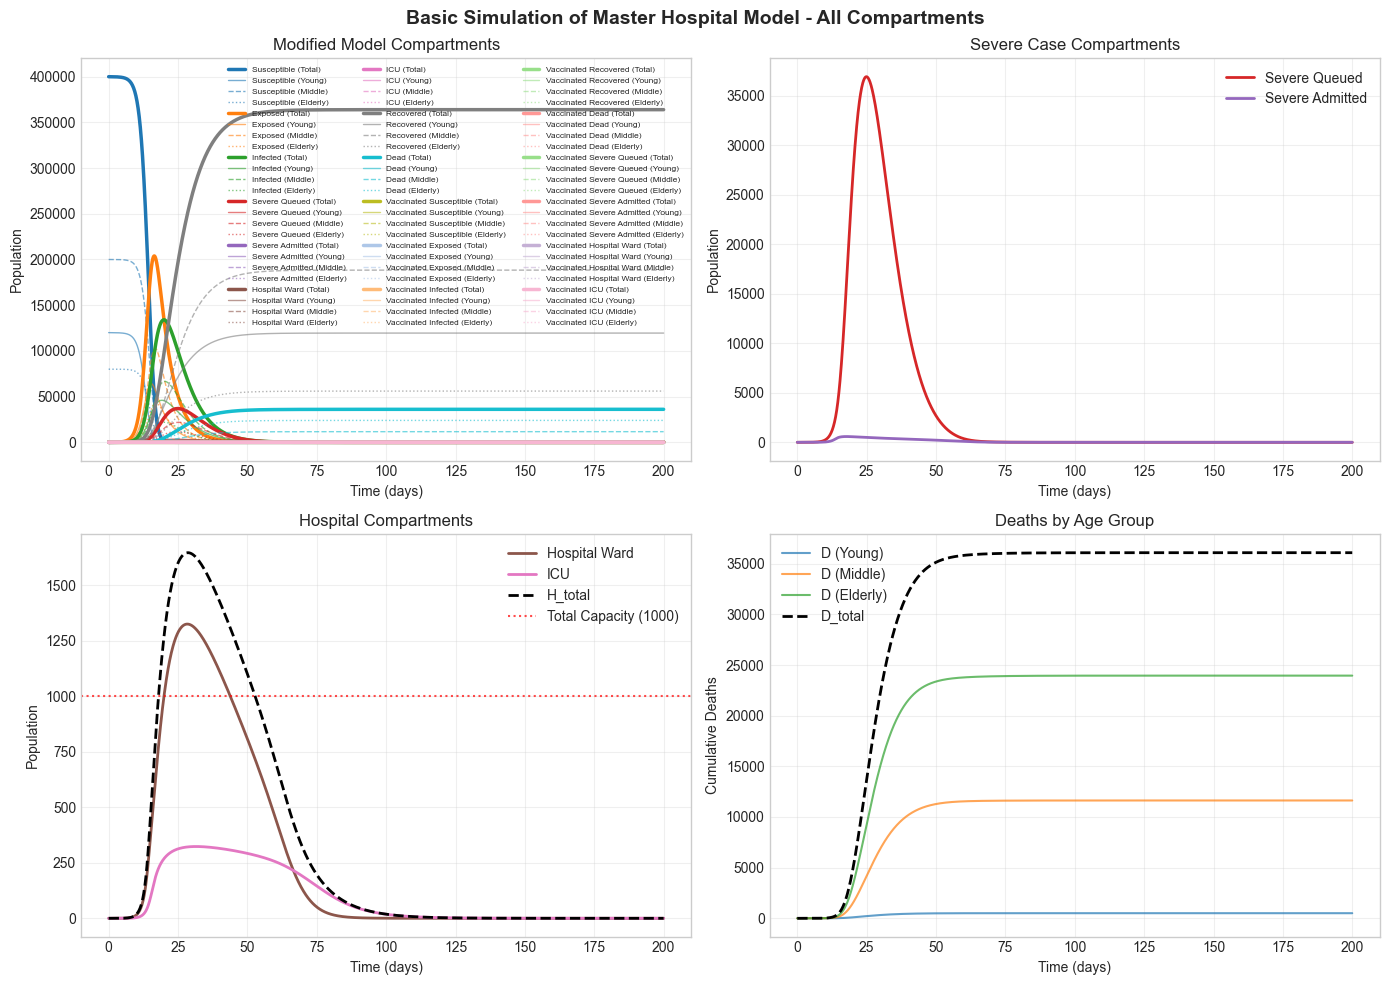

In [23]:
# basic simulation where every compartment is plotted over time
def plot_basic_simulation(params):
    result = simulate_master_hospital_model(**params)
    t = result['times']
    
    # Define all compartments with their display names and colors
    compartments = {
        'S': ('Susceptible', '#1f77b4'),
        'E': ('Exposed', '#ff7f0e'),
        'I': ('Infected', '#2ca02c'),
        'X_queued': ('Severe Queued', '#d62728'),
        'X_admitted': ('Severe Admitted', '#9467bd'),
        'H_ward': ('Hospital Ward', '#8c564b'),
        'H_icu': ('ICU', '#e377c2'),
        'R': ('Recovered', '#7f7f7f'),
        'D': ('Dead', '#17becf'),
        'S_vax': ('Vaccinated Susceptible', '#bcbd22'),
        'E_vax': ('Vaccinated Exposed', '#aec7e8'),
        'I_vax': ('Vaccinated Infected', '#ffbb78'),
        'X_queued_vax': ('Vaccinated Severe Queued', '#98df8a'),
        'X_admitted_vax': ('Vaccinated Severe Admitted', '#ff9896'),
        'H_ward_vax': ('Vaccinated Hospital Ward', '#c5b0d5'),
        'H_icu_vax': ('Vaccinated ICU', '#f7b6d2'),
        'R_vax': ('Vaccinated Recovered', '#98df8a'),
        'D_vax': ('Vaccinated Dead', '#ff9896'),
    }
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Panel 1: Main population compartments - total and by age
    ax1 = axes[0, 0]
    age_labels = ['Young', 'Middle', 'Elderly']
    linestyles = ['-', '--', ':']  # Different linestyle per age group

    for comp in ['S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D', 'S_vax', 'E_vax', 'I_vax', 'R_vax', 'D_vax', 'X_queued_vax', 'X_admitted_vax', 'H_ward_vax', 'H_icu_vax']:
        label, color = compartments[comp]
        # Plot total (solid, thick)
        data_total = np.sum(result[comp], axis=0)
        ax1.plot(t, data_total, label=f'{label} (Total)', color=color, linewidth=2.5)
        
        # Plot by age group (thinner, different linestyles)
        for age_idx, (age_label, ls) in enumerate(zip(age_labels, linestyles)):
            if age_idx < len(result[comp]):
                ax1.plot(t, result[comp][age_idx], label=f'{label} ({age_label})', 
                        color=color, linewidth=1, linestyle=ls, alpha=0.6)

    ax1.set_xlabel('Time (days)')
    ax1.set_ylabel('Population')
    ax1.set_title('Modified Model Compartments')
    ax1.legend(fontsize=6, ncol=3, loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Panel 2: Severe case compartments (X_queued, X_admitted)
    ax2 = axes[0, 1]
    for comp in ['X_queued', 'X_admitted']:
        label, color = compartments[comp]
        data = np.sum(result[comp], axis=0)
        ax2.plot(t, data, label=label, color=color, linewidth=2)
    ax2.set_xlabel('Time (days)')
    ax2.set_ylabel('Population')
    ax2.set_title('Severe Case Compartments')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Panel 3: Hospital compartments (H_ward, H_icu)
    ax3 = axes[1, 0]
    for comp in ['H_ward', 'H_icu']:
        label, color = compartments[comp]
        data = np.sum(result[comp], axis=0)
        ax3.plot(t, data, label=label, color=color, linewidth=2)
    # Add total hospitalized
    ax3.plot(t, result['H_total'], label='H_total', color='black', 
             linewidth=2, linestyle='--')
    # Add capacity line if available
    if 'ward_capacity' in result and 'icu_capacity' in result:
        total_cap = result['ward_capacity'] + result['icu_capacity']
        ax3.axhline(y=total_cap, color='red', linestyle=':', 
                    label=f'Total Capacity ({total_cap})', alpha=0.7)
    ax3.set_xlabel('Time (days)')
    ax3.set_ylabel('Population')
    ax3.set_title('Hospital Compartments')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Panel 4: Deaths (D by age and total)
    ax4 = axes[1, 1]
    label, color = compartments['D']
    # Plot deaths by age group if available
    for age_idx, age_label in enumerate(['Young', 'Middle', 'Elderly']):
        if age_idx < len(result['D']):
            ax4.plot(t, result['D'][age_idx], label=f'D ({age_label})', 
                     linewidth=1.5, alpha=0.7)
    ax4.plot(t, result['D_total'], label='D_total', color='black', 
             linewidth=2, linestyle='--')
    ax4.set_xlabel('Time (days)')
    ax4.set_ylabel('Cumulative Deaths')
    ax4.set_title('Deaths by Age Group')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle('Basic Simulation of Master Hospital Model - All Compartments', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../results/basic_simulation.png', dpi=150, bbox_inches='tight')
    plt.show()

# Example usage:
params = get_scenario_params('baseline')
plot_basic_simulation(params)

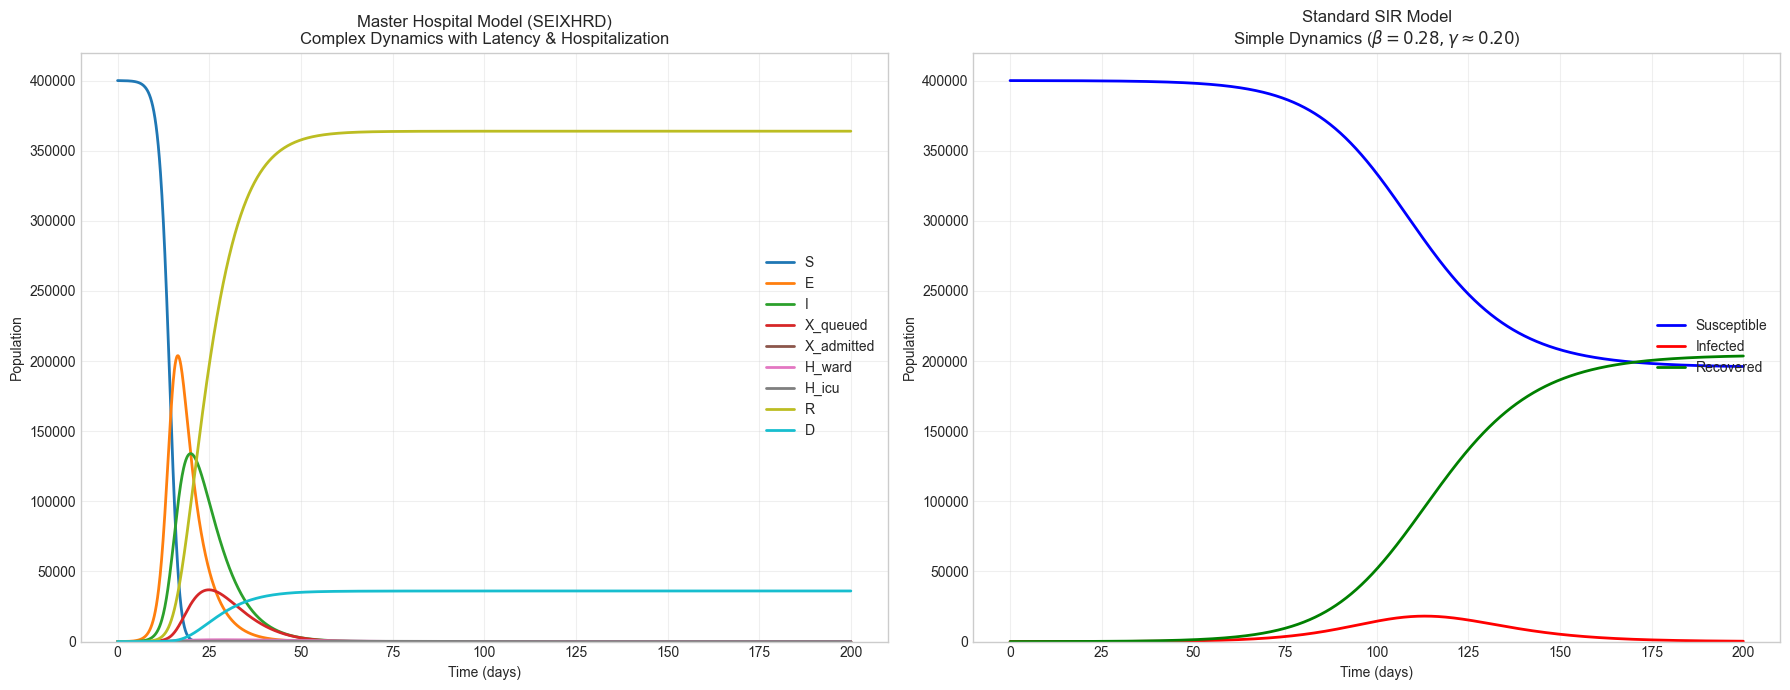

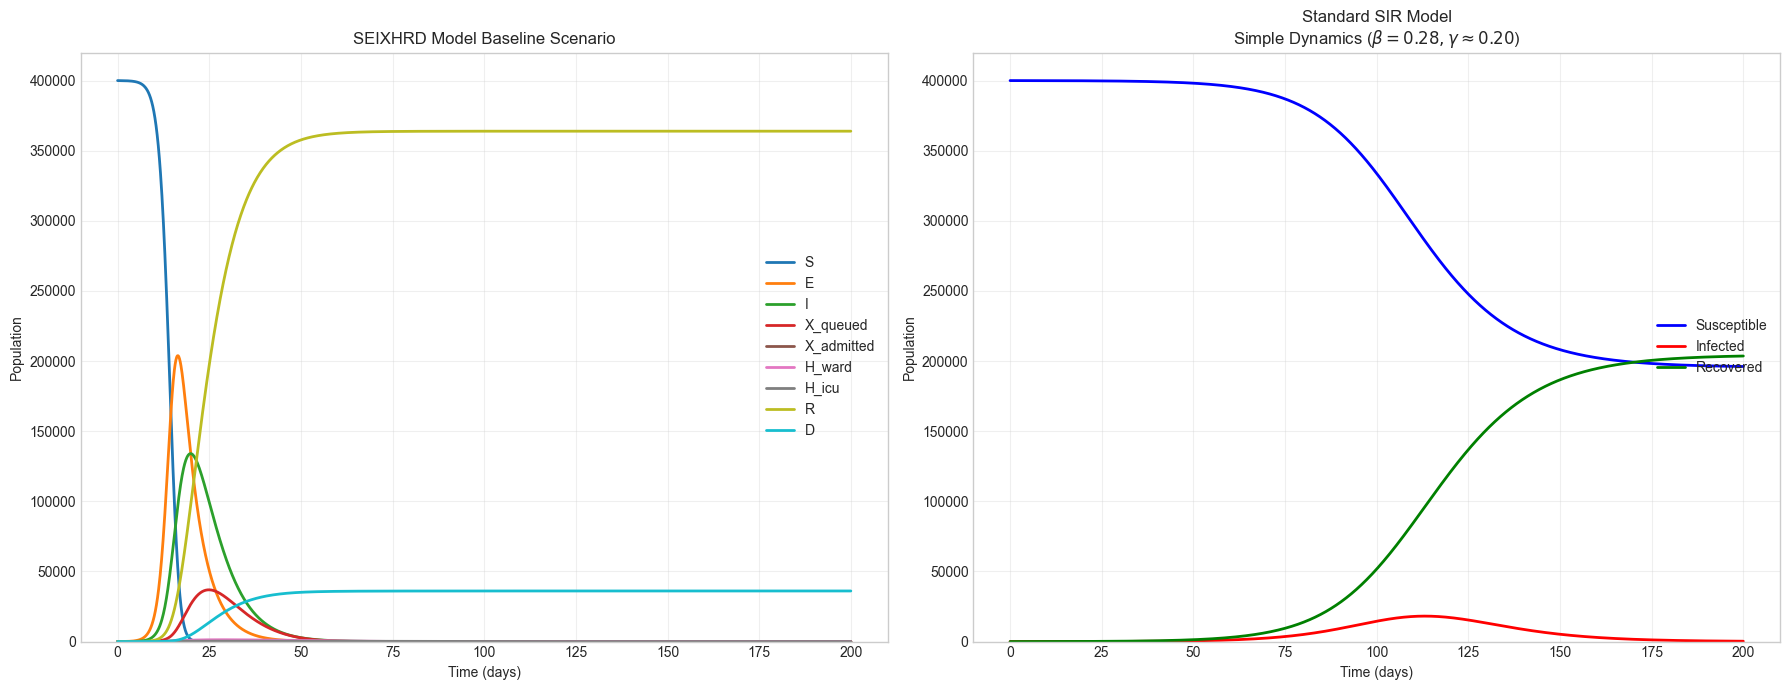

Comparison Notes:
- Master Hospital Model captures latency, hospitalization, and mortality dynamics.
- Standard SIR model is simpler but misses critical healthcare system interactions.


In [24]:
# Comparison: Master Hospital Model (SEIXHRD) vs Standard SIR
from scipy.integrate import odeint

# 1. Setup and Run Master Model
# -----------------------------
params = get_scenario_params('baseline')
# Disable vaccination for fair comparison with basic SIR
params['vaccine_config']['vaccination_rate'] = [0, 0, 0]
params['vaccine_config']['coverage'] = 0
# Ensure we have a clean run
res_master = simulate_master_hospital_model(**params)

# 2. Setup and Run Standard SIR Model
# -----------------------------------
# Extract aggregate parameters to make SIR comparable
N_total = sum(params['age_pops'])
I_initial = res_master['I_total'][0]
S_initial = N_total - I_initial
R_initial = 0

# Rate estimation
beta = params['beta_base']
# Effective recovery rate gamma for SIR:
# In Master model, I leaves via recovery (gamma_I) or progression (sigma)
# We take the weighted average from the middle age group as representative
age_p = params['age_params'][1] 
gamma_eff = age_p['gamma_I'] + age_p['sigma']

def deriv_sir(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

t = res_master['times']
y0 = S_initial, I_initial, R_initial
ret = odeint(deriv_sir, y0, t, args=(N_total, beta, gamma_eff))
S_sir, I_sir, R_sir = ret.T

# 3. Visualization
# ----------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left Plot: Master Hospital Model (All Compartments)
ax1 = axes[0]
# Sum compartments across age groups for cleaner visualization
compartments = ['S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D']
colors = plt.cm.tab10(np.linspace(0, 1, len(compartments)))

for i, comp in enumerate(compartments):
    # Sum the age-stratified arrays for this compartment
    data = np.sum(res_master[comp], axis=0)
    ax1.plot(t, data, label=comp, color=colors[i], linewidth=2)

ax1.set_title('Master Hospital Model (SEIXHRD)\nComplex Dynamics with Latency & Hospitalization')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Population')
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Right Plot: Standard SIR Model
ax2 = axes[1]
ax2.plot(t, S_sir, label='Susceptible', color='blue', linewidth=2)
ax2.plot(t, I_sir, label='Infected', color='red', linewidth=2)
ax2.plot(t, R_sir, label='Recovered', color='green', linewidth=2)

ax2.set_title(f'Standard SIR Model\nSimple Dynamics ($\\beta={beta}, \\gamma\\approx{gamma_eff:.2f}$)')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Population')
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../results/model_complexity_comparison.png', dpi=150, bbox_inches='tight')
# Comparison: Master Hospital Model (SEIXHRD) vs Standard SIR
from scipy.integrate import odeint

# 1. Setup and Run Master Model
# -----------------------------
params = get_scenario_params('baseline')
# Disable vaccination for fair comparison with basic SIR
params['vaccine_config']['vaccination_rate'] = [0, 0, 0]
params['vaccine_config']['coverage'] = 0
# Ensure we have a clean run
res_master = simulate_master_hospital_model(**params)

# 2. Setup and Run Standard SIR Model
# -----------------------------------
# Extract aggregate parameters to make SIR comparable
N_total = sum(params['age_pops'])
I_initial = res_master['I_total'][0]
S_initial = N_total - I_initial
R_initial = 0

# Rate estimation
beta = params['beta_base']
# Effective recovery rate gamma for SIR:
# In Master model, I leaves via recovery (gamma_I) or progression (sigma)
# We take the weighted average from the middle age group as representative
age_p = params['age_params'][1] 
gamma_eff = age_p['gamma_I'] + age_p['sigma']

def deriv_sir(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return dSdt, dIdt, dRdt

t = res_master['times']
y0 = S_initial, I_initial, R_initial
ret = odeint(deriv_sir, y0, t, args=(N_total, beta, gamma_eff))
S_sir, I_sir, R_sir = ret.T

# 3. Visualization
# ----------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left Plot: Master Hospital Model (All Compartments)
ax1 = axes[0]
# Sum compartments across age groups for cleaner visualization
compartments = ['S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D']
colors = plt.cm.tab10(np.linspace(0, 1, len(compartments)))

for i, comp in enumerate(compartments):
    # Sum the age-stratified arrays for this compartment
    data = np.sum(res_master[comp], axis=0)
    ax1.plot(t, data, label=comp, color=colors[i], linewidth=2)

ax1.set_title('SEIXHRD Model Baseline Scenario')
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Population')
ax1.legend(loc='center right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Right Plot: Standard SIR Model
ax2 = axes[1]
ax2.plot(t, S_sir, label='Susceptible', color='blue', linewidth=2)
ax2.plot(t, I_sir, label='Infected', color='red', linewidth=2)
ax2.plot(t, R_sir, label='Recovered', color='green', linewidth=2)

ax2.set_title(f'Standard SIR Model\nSimple Dynamics ($\\beta={beta}, \\gamma\\approx{gamma_eff:.2f}$)')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('Population')
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../results/model_complexity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Comparison Notes:")
print("- Master Hospital Model captures latency, hospitalization, and mortality dynamics.")
print("- Standard SIR model is simpler but misses critical healthcare system interactions.")

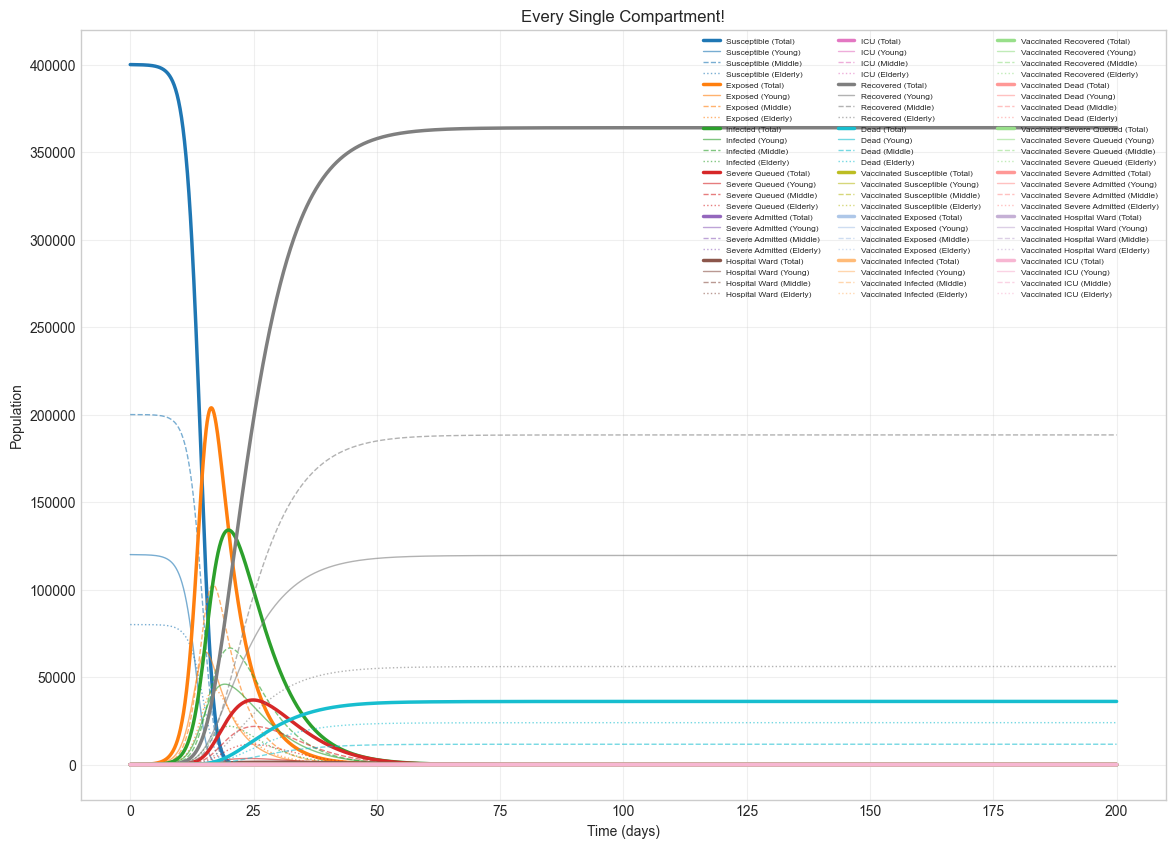

In [25]:
result = simulate_master_hospital_model(**params)
t = result['times']

# Define all compartments with their display names and colors
compartments = {
    'S': ('Susceptible', '#1f77b4'),
    'E': ('Exposed', '#ff7f0e'),
    'I': ('Infected', '#2ca02c'),
    'X_queued': ('Severe Queued', '#d62728'),
    'X_admitted': ('Severe Admitted', '#9467bd'),
    'H_ward': ('Hospital Ward', '#8c564b'),
    'H_icu': ('ICU', '#e377c2'),
    'R': ('Recovered', '#7f7f7f'),
    'D': ('Dead', '#17becf'),
    'S_vax': ('Vaccinated Susceptible', '#bcbd22'),
    'E_vax': ('Vaccinated Exposed', '#aec7e8'),
    'I_vax': ('Vaccinated Infected', '#ffbb78'),
    'X_queued_vax': ('Vaccinated Severe Queued', '#98df8a'),
    'X_admitted_vax': ('Vaccinated Severe Admitted', '#ff9896'),
    'H_ward_vax': ('Vaccinated Hospital Ward', '#c5b0d5'),
    'H_icu_vax': ('Vaccinated ICU', '#f7b6d2'),
    'R_vax': ('Vaccinated Recovered', '#98df8a'),
    'D_vax': ('Vaccinated Dead', '#ff9896'),
}

fig, axes = plt.subplots(1, 1, figsize=(14, 10))

# Panel 1: Main population compartments - total and by age
ax1 = axes
age_labels = ['Young', 'Middle', 'Elderly']
linestyles = ['-', '--', ':']  # Different linestyle per age group

for comp in ['S', 'E', 'I', 'X_queued', 'X_admitted', 'H_ward', 'H_icu', 'R', 'D', 'S_vax', 'E_vax', 'I_vax', 'R_vax', 'D_vax', 'X_queued_vax', 'X_admitted_vax', 'H_ward_vax', 'H_icu_vax']:
    label, color = compartments[comp]
    # Plot total (solid, thick)
    data_total = np.sum(result[comp], axis=0)
    ax1.plot(t, data_total, label=f'{label} (Total)', color=color, linewidth=2.5)
    
    # Plot by age group (thinner, different linestyles)
    for age_idx, (age_label, ls) in enumerate(zip(age_labels, linestyles)):
        if age_idx < len(result[comp]):
            ax1.plot(t, result[comp][age_idx], label=f'{label} ({age_label})', 
                    color=color, linewidth=1, linestyle=ls, alpha=0.6)

ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Population')
ax1.set_title('Every Single Compartment!')
ax1.legend(fontsize=6, ncol=3, loc='upper right')
ax1.grid(True, alpha=0.3)
plt.savefig('../results/basic_simulation_all_compartments.png', dpi=150, bbox_inches='tight')
    
    